In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import urllib.request
import numpy as np

urllib.request.urlretrieve(
    "https://github.com/google/fonts/raw/main/ofl/ibmplexmono/IBMPlexMono-Regular.ttf",
    "IBMPlexMono-Regular.ttf",
)
fe = font_manager.FontEntry(fname="IBMPlexMono-Regular.ttf", name="plexmono")
font_manager.fontManager.ttflist.append(fe)
plt.rcParams.update(
    {
        "axes.facecolor": "#f5f4e9",
        "grid.color": "#AAAAAA",
        "axes.edgecolor": "#333333",
        "figure.facecolor": "#FFFFFF",
        "axes.grid": False,
        "axes.prop_cycle": plt.cycler("color", plt.cm.Dark2.colors),
        "font.family": fe.name,
        "figure.figsize": (3.5, 3.5 / 1.2),
        "ytick.left": True,
        "xtick.bottom": True,
    }
)

import random
np.random.seed(0)
random.seed(0)

In [141]:
transition_metals = [
    "Ag",  
    "Au",
    "Bh", 
    "Cd", 
    "Co",
    "Cr",  
    "Cu",
    "Db", 
    "Ds", 
    "Fe",  
    "Fl",  
    "Hf", 
    "Hg", 
    "Hs", 
    "Ir", 
    "Lv",  
    "Mc", 
    "Mn", 
    "Mo",  
    "Mt",  
    "Nb", 
    "Ni",
    "Nh",  
    "Og",  
    "Os",
    "Pd",  
    "Pt",  
    "Rf",  
    "Rh", 
    "Rg",  
    "Ru", 
    "Sg",  
    "Sc",  
    "Ta",  
    "Tc", 
    "Ti",  
    "Ts",  
    "V",   
    "W",   
    "Y",  
    "Zr",
    "Zn",   
]


In [5]:
# ============================================================
# eval_embeddings_bert_comparison.py
# ============================================================
# Compares three embedding models on Mo-carburization procedures:
#   - OpenAI text-embedding-ada-002
#   - OpenAI text-embedding-3-large
#   - materialBERT (m3rg-iitd/matscibert)
#
# Context modes are implemented as POST-HOC VECTOR OPERATIONS
# rather than string concatenation. This means:
#   - All models receive identical single-procedure inputs
#   - No 512-token truncation for BERT
#   - NPZ cache hits for reference + context procedures
#   - Fully comparable results across all three models
#
# Scoring modes
# -------------
#   RAW        cosine(ref, var)
#   PROJ_ref1  project out new_ref1 direction, then cosine
#   PROJ_ref2  project out new_ref2 direction, then cosine
#   PROJ_both  project out mean(ref1, ref2) direction, then cosine
#   DIFF_both  subtract mean(ref1, ref2) from both, then cosine
#
# Outputs: scores_bert_comparison.csv  |  swap_table_bert_comparison.csv
#          figures_bert/<mode>/<name>.{png,pdf}
# ============================================================

from __future__ import annotations
import os, re, unicodedata, warnings
from typing import Dict, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

# ── CONFIG ───────────────────────────────────────────────────────────────────
NPZ_PATH = "/Users/shane/repos/boicl_crystal_phase_isolation/dataset/data/matscibert_embeddings.npz"
BERT_MODEL_NAME  = "m3rg-iitd/matscibert"
BERT_MODEL_PATH: Optional[str] = None   # local dir, or None → HF Hub
BERT_BATCH_SIZE  = 32
BERT_DEVICE: Optional[str] = None       # None → auto

OPENAI_MODELS = {
    "ada-002": "text-embedding-ada-002",
    "3-large": "text-embedding-3-large",
}
ALL_MODELS = list(OPENAI_MODELS) + ["matscibert"]
N_NOISE_DUPES = 16
OUTDIR = "figures_bert"
os.makedirs(OUTDIR, exist_ok=True)

openai_client = OpenAI()

plt.rcParams.update({
    "figure.figsize": (13.33, 7.5), "figure.dpi": 150, "savefig.dpi": 300,
    "font.size": 16, "axes.titlesize": 18, "axes.labelsize": 16,
    "xtick.labelsize": 13, "ytick.labelsize": 13, "legend.fontsize": 14,
})

# ── REFERENCE & CONTEXT PROCEDURES  (all real dataset entries) ───────────────
reference_text = (
    "Dissolve 1 g ammonium heptamolybdate tetrahydrate in 6 mL DI water. "
    "Dissolve 1 g sucrose in 1.5 mL DI water. "
    "Combine; stir 15 min at 300 RPM; dry at 120 °C in air for 24 hr. "
    "Crush. Load 1 g into crucible; ramp 15 °C/min to 644.9 °C, hold 3.92 hr under 30 ccm H2. "
    "Cool under 30 ccm N2 to <30 °C. "
    "Passivate under 30 ccm 1% O2/N2 for 2 hr."
)
new_ref1 = (                            # lower temp, long hold
    "Dissolve 1 g ammonium heptamolybdate tetrahydrate in 6 mL DI water. "
    "Dissolve 1 g sucrose in 1.5 mL DI water. "
    "Combine; stir 15 min at 300 RPM; dry at 120 °C in air for 24 hr. "
    "Crush. Load 1 g into crucible; ramp 15 °C/min to 491.8 °C, hold 24.00 hr under 30 ccm H2. "
    "Cool under 30 ccm N2 to <30 °C. "
    "Passivate under 30 ccm 1% O2/N2 for 2 hr."
)
new_ref2 = (                            # higher temp, long hold
    "Dissolve 1 g ammonium heptamolybdate tetrahydrate in 6 mL DI water. "
    "Dissolve 1 g sucrose in 1.5 mL DI water. "
    "Combine; stir 15 min at 300 RPM; dry at 120 °C in air for 24 hr. "
    "Crush. Load 1 g into crucible; ramp 15 °C/min to 798.0 °C, hold 24.00 hr under 30 ccm H2. "
    "Cool under 30 ccm N2 to <30 °C. "
    "Passivate under 30 ccm 1% O2/N2 for 2 hr."
)

# Unit equivalents for the reference values
T_REF, H_REF = 644.9, 3.92
T_K   = T_REF + 273.15          # 918.05 K
T_F   = T_REF * 9/5 + 32        # 1192.82 °F
H_MIN = H_REF * 60              # 235.2 min
H_S   = int(H_MIN * 60)         # 14112 s

# ── SCORING MODES  (vector operations, not string concatenation) ─────────────

def _l2(v: np.ndarray) -> np.ndarray:
    return v / (np.linalg.norm(v) + 1e-12)

def _project_out(vec: np.ndarray, axis: np.ndarray) -> np.ndarray:
    """Remove the component of vec along axis."""
    a = _l2(axis)
    return vec - np.dot(vec, a) * a

def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    return float(sk_cosine([a], [b])[0][0])

def score_raw(ref_v, var_v, ctx_vecs):
    return cosine_sim(ref_v, var_v)

def score_proj(ref_v, var_v, ctx_vecs):
    """Project both vectors onto subspace orthogonal to mean(ctx) before comparing."""
    axis = np.mean(ctx_vecs, axis=0)
    return cosine_sim(_project_out(ref_v, axis), _project_out(var_v, axis))

def score_diff(ref_v, var_v, ctx_vecs):
    """Subtract mean(ctx) from both before comparing (soft centering)."""
    bg = np.mean(ctx_vecs, axis=0)
    return cosine_sim(ref_v - bg, var_v - bg)

# ctx_keys: which context embeddings to pass to the scoring function
SCORE_MODES: Dict[str, dict] = {
    "RAW":          dict(fn=score_raw,  ctx_keys=[]),
    "PROJ_ref1":    dict(fn=score_proj, ctx_keys=["new_ref1"]),
    "PROJ_ref2":    dict(fn=score_proj, ctx_keys=["new_ref2"]),
    "PROJ_both":    dict(fn=score_proj, ctx_keys=["new_ref1", "new_ref2"]),
    "DIFF_both":    dict(fn=score_diff, ctx_keys=["new_ref1", "new_ref2"]),
}
PLOT_MODES = list(SCORE_MODES)

# ── HELPERS ───────────────────────────────────────────────────────────────────

def canonicalize(t: str) -> str:
    return unicodedata.normalize("NFC", t.replace("\n", " "))

def _sub1(text, pat, repl, tag):
    out, n = re.subn(pat, repl, text)
    if n != 1:
        raise ValueError(f"[{tag}] expected 1 match; got {n}")
    return out

def replace_temp(text, repl):
    return _sub1(text, r"(ramp 15 °C/min to)\s*644\.9\s*°C", rf"\1 {repl}", "temp")
def replace_hold(text, repl):
    return _sub1(text, r"(hold)\s*3\.92\s*hr", rf"\1 {repl}", "hold")
def replace_gas(text, g):
    return _sub1(text, r"(hold \S+ hr under 30 ccm\s+)H2\b", rf"\g<1>{g}", "gas")
def replace_ramp(text, repl):
    return _sub1(text, r"ramp 15 °C/min", f"ramp {repl}", "ramp")

def group_stats(v: np.ndarray) -> dict:
    v = np.asarray(v, dtype=float)
    if not len(v):
        return dict(mean=np.nan, q25=np.nan, q75=np.nan, n=0)
    return dict(mean=float(v.mean()), q25=float(np.quantile(v, .25)),
                q75=float(np.quantile(v, .75)), n=int(len(v)))

def icon(ok): return "✅" if ok else "❌"

def save_fig(name, mode=None):
    d = os.path.join(OUTDIR, mode) if mode else OUTDIR
    os.makedirs(d, exist_ok=True)
    for ext in ("png", "pdf"):
        p = os.path.join(d, f"{name}.{ext}")
        plt.savefig(p, bbox_inches="tight")
        print(f"  {p}")

# ── OPENAI EMBEDDER ───────────────────────────────────────────────────────────

def embed_openai(texts: List[str], model_name: str) -> List[np.ndarray]:
    texts = [canonicalize(t) for t in texts]
    resp  = openai_client.embeddings.create(model=model_name, input=texts)
    return [np.array(d.embedding) for d in sorted(resp.data, key=lambda d: d.index)]

# ── HYBRID BERT EMBEDDER  (cache-first, live fallback) ────────────────────────

class HybridBertEmbedder:
    """
    Looks up texts in the pre-computed NPZ cache first.
    Only cache misses (the variants) trigger live BERT inference.

    Because all inputs are now single bare procedures (no string concatenation),
    the reference and context procedures are guaranteed cache hits.
    """

    def __init__(self, npz_path: Optional[str],
                 model_name=BERT_MODEL_NAME,
                 model_path: Optional[str] = None,
                 device: Optional[str] = None,
                 batch_size: int = BERT_BATCH_SIZE) -> None:
        self._cache: Dict[str, np.ndarray] = {}
        if npz_path and os.path.exists(npz_path):
            data  = np.load(npz_path, allow_pickle=True)
            procs = data["procedures"].tolist()
            embs  = data["embeddings"]
            self._cache = {canonicalize(p): embs[i] for i, p in enumerate(procs)}
            print(f"[BERT] Loaded {len(self._cache):,} cached embeddings")
        elif npz_path:
            warnings.warn(f"NPZ not found at {npz_path!r} — will use live BERT for all texts.")
        self._model_name  = model_name
        self._model_path  = model_path
        self._device      = device
        self._batch_size  = batch_size
        self._tok = self._mdl = None

    def _load(self):
        if self._mdl is not None:
            return
        import torch
        from transformers import BertTokenizer, BertModel
        dev    = self._device or ("cuda" if torch.cuda.is_available() else "cpu")
        src    = self._model_path or self._model_name
        print(f"[BERT] Loading live model {src} on {dev} …")
        try:
            self._tok = BertTokenizer.from_pretrained(src)
            self._mdl = BertModel.from_pretrained(src, add_pooling_layer=False)
        except Exception as e:
            raise RuntimeError(
                f"Could not load matscibert from {src!r}.\n"
                "Set BERT_MODEL_PATH to a local checkpoint, or ensure HF Hub is reachable.\n"
                f"Error: {e}"
            ) from e
        self._mdl.eval().to(dev)
        self._dev = dev
        print("[BERT] Live model ready.")

    def _embed_live(self, texts: List[str]) -> List[np.ndarray]:
        import torch
        self._load()
        out = []
        for i in range(0, len(texts), self._batch_size):
            batch = [canonicalize(t) for t in texts[i: i + self._batch_size]]
            enc   = self._tok(batch, return_tensors="pt", truncation=True,
                              max_length=512, padding=True).to(self._dev)
            with torch.no_grad():
                h = self._mdl(**enc).last_hidden_state
            mask = enc["attention_mask"].unsqueeze(-1).float()
            vecs = (h * mask).sum(1) / mask.sum(1).clamp(min=1e-8)
            out.extend(vecs.cpu().numpy())
        return out

    def embed(self, texts: List[str]) -> List[np.ndarray]:
        result = [None] * len(texts)
        miss_i, miss_t = [], []
        for i, t in enumerate(texts):
            v = self._cache.get(canonicalize(t))
            if v is not None:
                result[i] = v
            else:
                miss_i.append(i); miss_t.append(t)
        n_hit = len(texts) - len(miss_i)
        if miss_i:
            print(f"  [BERT] cache hits={n_hit}, misses={len(miss_i)} → live model")
            for idx, vec in zip(miss_i, self._embed_live(miss_t)):
                result[idx] = vec
        else:
            print(f"  [BERT] all {n_hit} from cache")
        return result

_bert: Optional[HybridBertEmbedder] = None
def get_bert() -> HybridBertEmbedder:
    global _bert
    if _bert is None:
        _bert = HybridBertEmbedder(NPZ_PATH, model_path=BERT_MODEL_PATH)
    return _bert

def embed(texts: List[str], model_label: str) -> List[np.ndarray]:
    if model_label == "matscibert":
        return get_bert().embed(texts)
    return embed_openai(texts, OPENAI_MODELS[model_label])

# ── VARIANTS ──────────────────────────────────────────────────────────────────

group_order = {
    "base": 0, "control_surface": 1,
    "temp_format_only": 2, "temp_replace_equiv": 3, "temp_replace_wrong": 4,
    "hold_format_only": 5, "hold_replace_equiv": 6, "hold_replace_wrong": 7,
    "gas_species": 8, "ramp_format_only": 9, "ramp_replace_equiv": 10,
}

def build_variants(ref: str) -> Tuple[Dict[str, str], pd.DataFrame]:
    variants: Dict[str, str] = {}
    meta = []

    def add(label, text, group, field="(none)", frm="", to="", note=""):
        variants[label] = text
        meta.append(dict(label=label, group=group, field=field,
                         **{"from": frm}, to=to, note=note))

    add("BASE (reference)", ref, "base")

    # Surface controls
    add("Control: double-space",      ref.replace(". ", ".  ", 1), "control_surface", "spacing")
    add("Control: remove comma",      ref.replace(",", "", 1),     "control_surface", "punctuation")
    add("Control: 30 ccm→30ccm",      ref.replace("30 ccm", "30ccm", 1), "control_surface", "spacing")
    add("Control: 1%→1 %",            ref.replace("1%", "1 %", 1), "control_surface", "spacing")

    # Temperature — format only (same number 644.9, different °C notation)
    for r in ["644.9°C", "644.9 C", "644.9 degC", "644.9 degrees C", "644.9 Celsius", "644.9 ° C"]:
        add(f"Temp format: {r}", replace_temp(ref, r), "temp_format_only", "carb_temp", "644.9 °C", r)

    # Temperature — correct unit conversions (number changes)
    for r in [f"{T_K:.2f} K", f"{T_K:.0f} K", f"{T_K:.1f} K",
              f"{T_F:.0f} °F", f"{T_F:.1f} °F", f"{T_F:.0f}°F", f"{T_F:.0f} degF"]:
        add(f"Temp equiv: {r}", replace_temp(ref, r), "temp_replace_equiv", "carb_temp", "644.9 °C", r)

    # Temperature — wrong unit, same number
    for r in ["644.9 K", "644.9 °F", "644.9°F", "644.9 degF", "644.9 degK"]:
        add(f"Temp WRONG: {r}", replace_temp(ref, r), "temp_replace_wrong", "carb_temp", "644.9 °C", r)

    # Hold time — format only (same number 3.92, different hr notation)
    for r in ["3.92 h", "3.92 hours", "3.92hr", "3.92 Hours"]:
        add(f"Hold format: {r}", replace_hold(ref, r), "hold_format_only", "hold_time", "3.92 hr", r)

    # Hold time — correct unit conversions
    for r in [f"{H_MIN:.1f} min", f"{H_MIN:.0f} min", "235.2 minutes",
              f"{H_S} s", f"{H_S} sec", f"{H_S} seconds"]:
        add(f"Hold equiv: {r}", replace_hold(ref, r), "hold_replace_equiv", "hold_time", "3.92 hr", r)

    # Hold time — wrong unit, same number
    for r in ["3.92 min", "3.92 minutes", "3.92 s", "3.92 sec"]:
        add(f"Hold WRONG: {r}", replace_hold(ref, r), "hold_replace_wrong", "hold_time", "3.92 hr", r)

    # Gas species
    add("Gas: H2 (baseline)", ref, "gas_species", "carb_gas", "H2", "H2", "baseline")
    for g in ["CH4", "CO", "Ar", "N2", "H2/CH4"]:
        add(f"Gas: H2→{g}", replace_gas(ref, g), "gas_species", "carb_gas", "H2", g, "species swap")

    # Ramp rate — format only
    for r in ["15°C/min", "15 C/min", "15 degC/min", "15 degrees C/min", "15°C min⁻¹"]:
        add(f"Ramp format: {r}", replace_ramp(ref, r), "ramp_format_only", "ramp_rate", "15 °C/min", r)

    # Ramp rate — correct unit conversions (15 °C/min = 0.25 °C/s = 900 °C/hr)
    for r in ["0.25 °C/s", "0.2500 °C/s", "0.250 °C/s", "900 °C/hr", "900 °C/h"]:
        add(f"Ramp equiv: {r}", replace_ramp(ref, r), "ramp_replace_equiv", "ramp_rate", "15 °C/min", r)

    assert variants["BASE (reference)"] == ref
    meta_df = pd.DataFrame(meta)
    print("=== Variants per group ===")
    print(meta_df.groupby("group")["label"].count().to_string())
    return variants, meta_df

variants, meta_df = build_variants(reference_text)

# ── EMBED ALL UNIQUE TEXTS ONCE PER MODEL ────────────────────────────────────
#
# All texts are single bare procedures — no string concatenation.
# For BERT: reference + context procs → cache hits; variants → cache misses.
# Total live BERT calls ≈ 53 (just the variants).

labels     = meta_df["label"].tolist()
var_texts  = [variants[l] for l in labels]
ctx_procs  = {"new_ref1": new_ref1, "new_ref2": new_ref2}
noise_text = reference_text   # embed once; duplicate vector for noise floor

# Unique texts to embed: [ref, new_ref1, new_ref2, noise×N, var×M]
# We send noise as a single embed and duplicate the vector afterward
all_unique  = [reference_text, new_ref1, new_ref2] + var_texts

# Store: model_label → {text_key: np.ndarray}
embeddings: Dict[str, Dict[str, np.ndarray]] = {}

for ml in ALL_MODELS:
    print(f"\n[Embedding] {ml}")
    vecs = embed(all_unique, ml)
    embeddings[ml] = {
        "reference":  vecs[0],
        "new_ref1":   vecs[1],
        "new_ref2":   vecs[2],
        **{label: vecs[3 + i] for i, label in enumerate(labels)},
    }
    # Noise floor: cosine distance between N duplicates of the reference vector
    # (deterministic models → delta ≈ 0; kept for comparability)
    ref_v = vecs[0]
    noise_deltas = [1.0 - cosine_sim(ref_v, ref_v)] * N_NOISE_DUPES   # = 0.0 for cached/det.
    embeddings[ml]["noise_p95"] = float(np.quantile(noise_deltas, 0.95))

print("\nAll embeddings complete.")

# ── SCORE UNDER EACH MODE ─────────────────────────────────────────────────────

rows = []
for mode_name, mode_cfg in SCORE_MODES.items():
    fn       = mode_cfg["fn"]
    ctx_keys = mode_cfg["ctx_keys"]
    for ml in ALL_MODELS:
        emb      = embeddings[ml]
        ref_v    = emb["reference"]
        ctx_vecs = [emb[k] for k in ctx_keys]   # empty list → RAW
        noise_p95 = emb["noise_p95"]

        for label in labels:
            var_v = emb[label]
            sim   = fn(ref_v, var_v, ctx_vecs)
            rows.append(dict(
                mode=mode_name, model=ml, label=label,
                cosine_similarity=sim,
                delta=1.0 - sim,
                noise_p95=noise_p95,
            ))

df_scores = pd.DataFrame(rows)
df        = meta_df.merge(df_scores, on="label", how="left")

# ── EXPORT ────────────────────────────────────────────────────────────────────

df.to_csv("scores_bert_comparison.csv", index=False)

swap_cols = ["mode", "model", "group", "field", "from", "to",
             "label", "cosine_similarity", "delta", "noise_p95", "note"]
df_table  = df[swap_cols].copy()
df_table["_r"] = df_table["group"].map(group_order)
(df_table
 .sort_values(["mode", "model", "_r", "delta"])
 .drop(columns="_r")
 .to_csv("swap_table_bert_comparison.csv", index=False))

print("Saved: scores_bert_comparison.csv  |  swap_table_bert_comparison.csv")

# ── TREND SUMMARY ─────────────────────────────────────────────────────────────

def vals(mdf, group, excl_baseline=False):
    sub = mdf[mdf["group"] == group]
    if excl_baseline:
        sub = sub[sub["note"] != "baseline"]
    return sub["delta"].values.astype(float)

print("\n=== Trend summary ===")
for mode_name in SCORE_MODES:
    dm = df[df["mode"] == mode_name]
    print(f"\n{'='*60}\nMODE: {mode_name}")
    for ml in ALL_MODELS:
        m = dm[dm["model"] == ml]
        st = {g: group_stats(vals(m, g, g == "gas_species"))
              for g in group_order if g != "base"}
        print(f"\n  {ml}")
        for k, s in st.items():
            print(f"    meanΔ[{k:28s}] = {s['mean']:.6f}  (n={s['n']})")
        print(f"    {icon(st['gas_species']['mean'] > st['temp_format_only']['mean'])}  gas > temp_format")
        print(f"    {icon(st['temp_replace_wrong']['mean'] >= st['temp_replace_equiv']['mean'])}  temp_wrong >= temp_equiv")
        print(f"    {icon(st['hold_replace_wrong']['mean'] >= st['hold_replace_equiv']['mean'])}  hold_wrong >= hold_equiv")
        print(f"    {icon(st['temp_replace_equiv']['mean'] > st['temp_format_only']['mean'])}  temp_equiv > temp_format")

# ── PLOTS ─────────────────────────────────────────────────────────────────────

def plot_group_means(df_in, mode, filename="group_means"):
    groups = [g for g in group_order if g != "base"]
    x, width = np.arange(len(groups)), 0.28
    plt.figure()
    for i, ml in enumerate(ALL_MODELS):
        m = df_in[df_in["model"] == ml]
        means, lo, hi = [], [], []
        for g in groups:
            sub = m[m["group"] == g]
            if g == "gas_species": sub = sub[sub["note"] != "baseline"]
            s = group_stats(sub["delta"].values.astype(float))
            means.append(s["mean"])
            lo.append(max(0.0, s["mean"] - s["q25"]))
            hi.append(max(0.0, s["q75"] - s["mean"]))
        offs = x + (i - (len(ALL_MODELS)-1)/2) * width
        plt.bar(offs, means, width=width, yerr=[lo, hi], capsize=5, label=ml)
    plt.xticks(x, groups, rotation=20, ha="right")
    plt.ylabel(r"$\Delta = 1 - \mathrm{cosine\_sim}$  ↓")
    plt.title(f"Group mean Δ with IQR  |  Mode: {mode}")
    plt.grid(axis="y", alpha=0.25); plt.legend(loc="upper left"); plt.tight_layout()
    save_fig(filename, mode=mode); plt.close()


def plot_heatmap(df_in, mode, filename="heatmap"):
    groups = [g for g in group_order if g != "base"]
    data   = np.zeros((len(groups), len(ALL_MODELS)))
    for j, ml in enumerate(ALL_MODELS):
        m = df_in[df_in["model"] == ml]
        for i, g in enumerate(groups):
            sub = m[m["group"] == g]
            if g == "gas_species": sub = sub[sub["note"] != "baseline"]
            data[i, j] = sub["delta"].mean()
    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(data, aspect="auto", cmap="RdYlGn_r")
    ax.set_xticks(range(len(ALL_MODELS))); ax.set_xticklabels(ALL_MODELS, fontsize=14)
    ax.set_yticks(range(len(groups)));    ax.set_yticklabels(groups, fontsize=12)
    plt.colorbar(im, ax=ax, label=r"mean $\Delta$")
    for i in range(len(groups)):
        for j in range(len(ALL_MODELS)):
            ax.text(j, i, f"{data[i,j]:.4f}", ha="center", va="center", fontsize=10)
    ax.set_title(f"mean Δ heatmap  |  Mode: {mode}", fontsize=14)
    plt.tight_layout(); save_fig(filename, mode=mode); plt.close()


def plot_variant_bars(df_in, mode, filename_prefix="variants"):
    for ml in ALL_MODELS:
        m = df_in[df_in["model"] == ml].copy()
        noise_p95 = float(m["noise_p95"].iloc[0])
        m["_r"] = m["group"].map(group_order)
        m = m.sort_values(["_r", "delta"])
        fig_h = max(8, 0.3 * len(m) + 2.5)
        plt.figure(figsize=(13.33, fig_h))
        y = np.arange(len(m))
        plt.barh(y, m["delta"].values)
        plt.yticks(y, [f"[{g}] {lab}" for g, lab in zip(m["group"], m["label"])], fontsize=9)
        plt.xlabel(r"$\Delta$  (lower = more similar)")
        plt.title(f"Per-variant Δ — {ml}  |  Mode: {mode}")
        plt.grid(axis="x", alpha=0.25)
        for yi, val in enumerate(m["delta"].values):
            plt.text(val, yi, f"  {val:.4f}", va="center", ha="left", fontsize=8)
        if noise_p95 > 1e-10:
            plt.axvline(noise_p95, linestyle="--", lw=1.5, color="red")
            plt.text(noise_p95, len(m)-0.5, f"noise p95={noise_p95:.2e}",
                     rotation=90, va="top", ha="right", fontsize=10, color="red")
        plt.tight_layout(); plt.gcf().subplots_adjust(left=0.45)
        save_fig(f"{filename_prefix}_{ml}", mode=mode); plt.close()


def plot_bert_vs_openai_scatter(df_in, mode, filename="scatter_bert_vs_openai"):
    bert = (df_in[df_in["model"] == "matscibert"]
            .set_index("label")["delta"].rename("bert"))
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    for ax, oai in zip(axes, ["ada-002", "3-large"]):
        oai_s = df_in[df_in["model"] == oai].set_index("label")["delta"].rename("oai")
        mrg   = pd.concat([bert, oai_s], axis=1).dropna()
        grp   = df_in[["label","group"]].drop_duplicates().set_index("label")["group"]
        mrg["group"] = mrg.index.map(grp)
        for g in mrg["group"].unique():
            sub = mrg[mrg["group"] == g]
            ax.scatter(sub["oai"], sub["bert"], label=g, alpha=0.7, s=55)
        lim = max(mrg["oai"].max(), mrg["bert"].max()) * 1.05
        ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.4)
        ax.set_xlabel(f"{oai} Δ"); ax.set_ylabel("matscibert Δ")
        ax.set_title(f"matscibert vs {oai}")
        ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.2)
    fig.suptitle(f"Per-variant Δ  |  Mode: {mode}", fontsize=15)
    plt.tight_layout(); save_fig(filename, mode=mode); plt.close()


def plot_mode_comparison(df_all, model_label, filename="mode_comparison"):
    """For one model: how does each scoring mode change the per-group mean Δ?"""
    groups = [g for g in group_order if g != "base"]
    modes  = list(SCORE_MODES)
    x, width = np.arange(len(groups)), 0.16
    plt.figure()
    for i, mode in enumerate(modes):
        dm = df_all[(df_all["mode"] == mode) & (df_all["model"] == model_label)]
        means = []
        for g in groups:
            sub = dm[dm["group"] == g]
            if g == "gas_species": sub = sub[sub["note"] != "baseline"]
            means.append(sub["delta"].mean())
        offs = x + (i - (len(modes)-1)/2) * width
        plt.bar(offs, means, width=width, label=mode)
    plt.xticks(x, groups, rotation=20, ha="right")
    plt.ylabel(r"mean $\Delta$")
    plt.title(f"Effect of scoring mode on group Δ  |  {model_label}")
    plt.grid(axis="y", alpha=0.25); plt.legend(fontsize=11); plt.tight_layout()
    save_fig(filename, mode=f"_model_{model_label}"); plt.close()


print("\n=== Plotting ===")
for mode_name in PLOT_MODES:
    dm = df[df["mode"] == mode_name]
    plot_group_means(dm,    mode_name)
    plot_heatmap(dm,        mode_name)
    plot_variant_bars(dm,   mode_name)
    plot_bert_vs_openai_scatter(dm, mode_name)

for ml in ALL_MODELS:
    plot_mode_comparison(df, ml)

print(f"\nDone. Results in scores_bert_comparison.csv and {OUTDIR}/")

=== Variants per group ===
group
base                  1
control_surface       4
gas_species           6
hold_format_only      4
hold_replace_equiv    6
hold_replace_wrong    4
ramp_format_only      5
ramp_replace_equiv    5
temp_format_only      6
temp_replace_equiv    7
temp_replace_wrong    5

[Embedding] ada-002

[Embedding] 3-large

[Embedding] matscibert
[BERT] Loaded 2,500 cached embeddings
  [BERT] cache hits=5, misses=51 → live model
[BERT] Loading live model m3rg-iitd/matscibert on cpu …


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1224.26it/s, Materializing param=encoder.layer.11.output.dense.weight]              
BertModel LOAD REPORT from: m3rg-iitd/matscibert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[BERT] Live model ready.

All embeddings complete.
Saved: scores_bert_comparison.csv  |  swap_table_bert_comparison.csv

=== Trend summary ===

MODE: RAW

  ada-002
    meanΔ[control_surface             ] = 0.000810  (n=4)
    meanΔ[temp_format_only            ] = 0.000201  (n=6)
    meanΔ[temp_replace_equiv          ] = 0.001184  (n=7)
    meanΔ[temp_replace_wrong          ] = 0.000553  (n=5)
    meanΔ[hold_format_only            ] = 0.000086  (n=4)
    meanΔ[hold_replace_equiv          ] = 0.000479  (n=6)
    meanΔ[hold_replace_wrong          ] = 0.000087  (n=4)
    meanΔ[gas_species                 ] = 0.001767  (n=5)
    meanΔ[ramp_format_only            ] = 0.000283  (n=5)
    meanΔ[ramp_replace_equiv          ] = 0.000691  (n=5)
    ✅  gas > temp_format
    ❌  temp_wrong >= temp_equiv
    ❌  hold_wrong >= hold_equiv
    ✅  temp_equiv > temp_format

  3-large
    meanΔ[control_surface             ] = 0.003230  (n=4)
    meanΔ[temp_format_only            ] = 0.002086  (n=6)
    mea

# Continuous Parameter Analysis: Temperature

3 Lowest Scores:
Temperature: 25 ºC, Score: 0.9865960240351771
Temperature: 50 ºC, Score: 0.9888916382227345
Temperature: 75 ºC, Score: 0.9900681394457636

3 Highest Scores:
Temperature: 950 ºC, Score: 0.9992928334363322
Temperature: 925 ºC, Score: 0.9993605357098375
Temperature: 850 ºC, Score: 0.9999902302757409


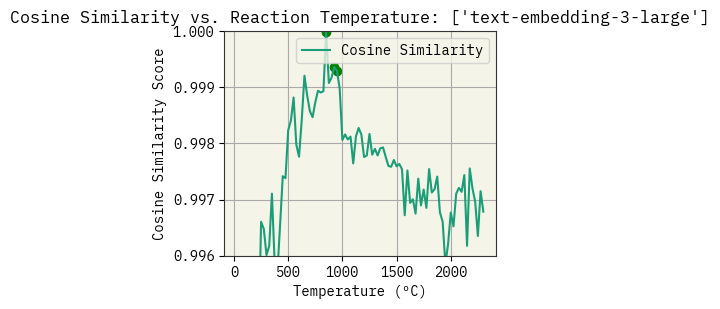

In [7]:

model = ["text-embedding-3-large"]
def compare_temperature_increment_batched(reference_text, start_temp, end_temp, step):
    temps = range(start_temp, end_temp + 1, step)
    modified_texts = [
        reference_text.replace("850 ºC", f"{temp} ºC")
        for temp in temps
    ]

    variation_embeddings = get_embeddings(modified_texts)

    scores = [
        cosine_sim(reference_embedding, variation.embedding)
        for variation in variation_embeddings
    ]

    return temps, scores

temperatures, scores = compare_temperature_increment_batched(reference_text, 25, 2300, 25)

scores_array = np.array(scores)
temperatures_array = np.array(temperatures)

lowest_indices = np.argsort(scores_array)[:3]
highest_indices = np.argsort(scores_array)[-3:]

print("3 Lowest Scores:")
for idx in lowest_indices:
    print(f"Temperature: {temperatures_array[idx]} ºC, Score: {scores_array[idx]}")

print("\n3 Highest Scores:")
for idx in highest_indices:
    print(f"Temperature: {temperatures_array[idx]} ºC, Score: {scores_array[idx]}")

plt.plot(temperatures_array, scores_array, label="Cosine Similarity")
plt.xlabel("Temperature (ºC)")
plt.ylabel("Cosine Similarity Score")
plt.ylim(.996, 1)
plt.title(f'Cosine Similarity vs. Reaction Temperature: {model}')
plt.grid(True)

def annotate_points(indices, color, y_offset=0, direction='up'):
    for i, idx in enumerate(indices):
        offset = 10 + (i * 15) if direction == 'up' else -(10 + (i * 15))
        plt.scatter(temperatures_array[idx], scores_array[idx], color=color)
        # plt.annotate(f'{temperatures_array[idx]} ºC',
        #              (temperatures_array[idx], scores_array[idx]),
        #              textcoords="offset points",
        #              xytext=(0, offset),  # Dynamic offset
        #              ha='center',
        #              color=color,
        #              arrowprops=dict(arrowstyle='->', color=color))

annotate_points(lowest_indices, 'red', direction='down')
annotate_points(highest_indices, 'green', direction='up')

plt.legend()
plt.show()

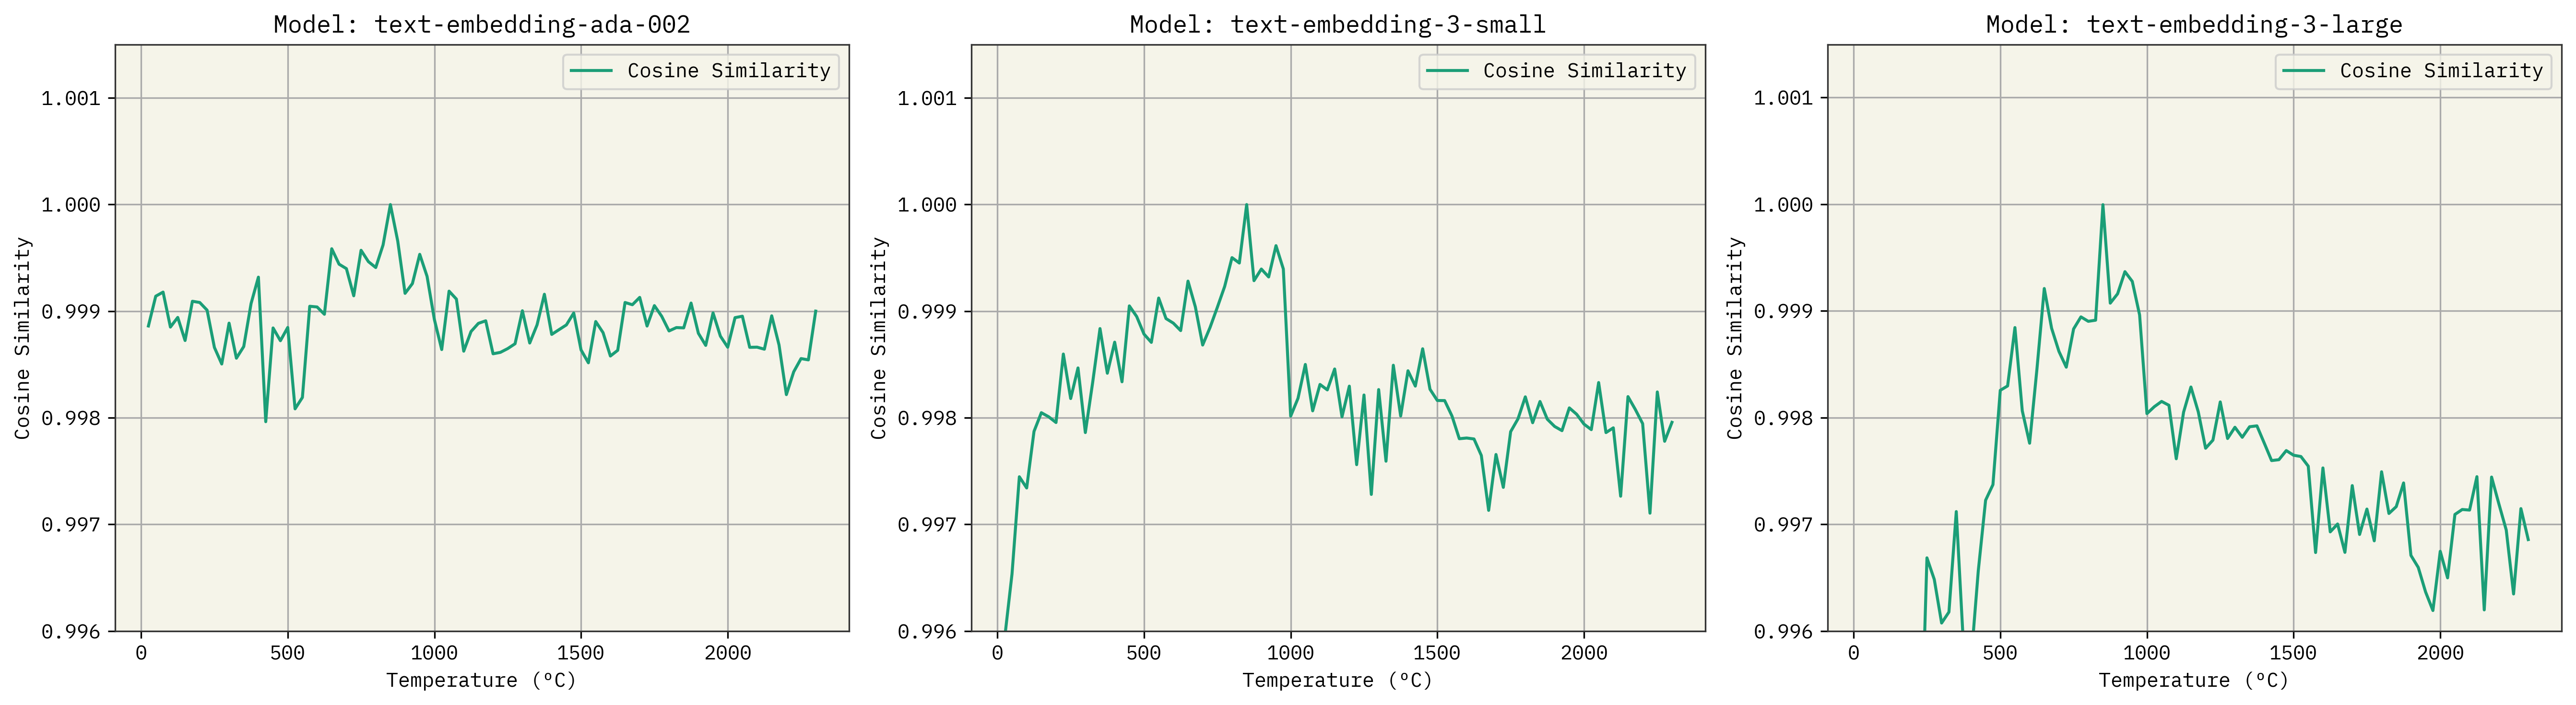

In [14]:
from openai import OpenAI
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

client = OpenAI()

models = ["text-embedding-ada-002", "text-embedding-3-small", "text-embedding-3-large"]

reference_text = (
    "To synthesize Mn-CaWO4/SiO2, SiO2 (1.0 g) was impregnated with 4.5 mL of an aqueous solution consisting of Mn (0.247 mol), Ca (0.185 mol), W (0.185 mol), at 50 ºC for 6 h. "
    "Once activated the reaction is ran at 850 ºC. The total flow rate was 10 mL/min (Ar: 4.0 mL/min, CH4: 4.8 mL/min, O2: 1.2 mL/min), leading to a contact time of 0.75 s."
)

def get_embeddings(texts, model):
    cleaned_texts = [text.replace("\n", " ") for text in texts]
    return client.embeddings.create(input=cleaned_texts, model=model).data

def cosine_sim(embedding1, embedding2):
    return cosine_similarity([embedding1], [embedding2])[0][0]

def compare_temperature_increment(reference_text, model, start_temp, end_temp, step):
    temps = list(range(start_temp, end_temp + 1, step))
    modified_texts = [
        reference_text.replace("850 ºC", f"{temp} ºC")
        for temp in temps
    ]

    reference_embedding = get_embeddings([reference_text], model=model)[0].embedding
    variation_embeddings = [e.embedding for e in get_embeddings(modified_texts, model=model)]

    scores = [cosine_sim(reference_embedding, emb) for emb in variation_embeddings]
    return temps, scores

def annotate_extremes(ax, temps, scores):
    temps = np.array(temps)
    scores = np.array(scores)
    # lowest = np.argsort(scores)[:3]
    # highest = np.argsort(scores)[-3:]

    # for idx in lowest:
    #     ax.scatter(temps[idx], scores[idx], color='red')
    #     ax.annotate(f"{temps[idx]}ºC", (temps[idx], scores[idx]), 
    #                 textcoords="offset points", xytext=(0, -10), ha='center', color='red')

    # for idx in highest:
    #     ax.scatter(temps[idx], scores[idx], color='green')
    #     ax.annotate(f"{temps[idx]}ºC", (temps[idx], scores[idx]), 
    #                 textcoords="offset points", xytext=(0, 10), ha='center', color='green')

    max_score = max(scores)
    ax.set_ylim(0.996, max_score + 0.0015)  # fixed y-axis lower bound

# Set up high-res figure
plt.figure(figsize=(18, 5), dpi=300)

for i, model in enumerate(models):
    temps, scores = compare_temperature_increment(reference_text, model, 25, 2300, 25)

    ax = plt.subplot(1, 3, i + 1)
    ax.plot(temps, scores, label="Cosine Similarity")
    ax.set_xlabel("Temperature (ºC)")
    ax.set_ylabel("Cosine Similarity")
    ax.set_title(f"Model: {model}")
    ax.grid(True)
    annotate_extremes(ax, temps, scores)
    ax.legend()

plt.tight_layout()
plt.show()


In [17]:
# ============================================================
# LOCAL NOTEBOOK CONFIG + CACHE-ONLY MATBERT LOADER
# Use this AFTER downloading matbert_variant_embeddings.npz from Colab
# ============================================================

from pathlib import Path
from typing import List, Dict, Optional
import unicodedata
import warnings
import numpy as np

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = Path(".").resolve()

# Downloaded from Colab. Put this file beside your notebook.
NPZ_VARIANTS_PATH = BASE_DIR / "/Users/shane/repos/boicl_crystal_phase_isolation/matbert_variant_embeddings (2).npz"

# Optional: your original dataset cache.
# If you have it, keep this path.
# If not, set this to None.
NPZ_DATASET_PATH = BASE_DIR / "/Users/shane/repos/boicl_crystal_phase_isolation/matbert_embeddings.npz"

# OpenAI cache if your notebook uses it.
OPENAI_CACHE_PATH = BASE_DIR / "openai_embedding_cache.pkl"

# Models to run.
# For full comparison:
ALL_MODELS = ["ada-002", "3-large", "matbert"]

# For debugging MatBERT only:
# ALL_MODELS = ["matbert"]

OPENAI_MODELS = {
    "ada-002": "text-embedding-ada-002",
    "3-large": "text-embedding-3-large",
}

print("BASE_DIR:", BASE_DIR)
print("NPZ_VARIANTS_PATH:", NPZ_VARIANTS_PATH, NPZ_VARIANTS_PATH.exists())
print("NPZ_DATASET_PATH:", NPZ_DATASET_PATH, NPZ_DATASET_PATH.exists() if NPZ_DATASET_PATH else None)

if not NPZ_VARIANTS_PATH.exists():
    raise FileNotFoundError(
        f"Missing {NPZ_VARIANTS_PATH}\n"
        "Move the downloaded matbert_variant_embeddings.npz from Colab into this notebook folder."
    )

# ============================================================
# NORMALIZATION HELPERS
# ============================================================

def canonicalize(t: str) -> str:
    """
    Match the exact text normalization used when exporting to Colab.
    Important: this preserves double spaces. It only removes newlines.
    """
    return unicodedata.normalize("NFC", str(t).replace("\n", " "))


# ============================================================
# CACHE-ONLY MATBERT LOADER
# ============================================================

class MatBertCacheOnly:
    """
    Loads MatBERT embeddings from NPZ files only.
    It never tries to load torch, transformers, or run MatBERT locally.
    """

    def __init__(
        self,
        dataset_npz_path: Optional[Path] = None,
        variants_npz_path: Optional[Path] = None,
    ):
        self.cache: Dict[str, np.ndarray] = {}

        self._load_npz(dataset_npz_path, label="dataset")
        self._load_npz(variants_npz_path, label="variants")

        if not self.cache:
            raise RuntimeError(
                "No MatBERT embeddings were loaded. Check NPZ paths."
            )

        print(f"[MatBERT] Total cached texts: {len(self.cache):,}")

    def _load_npz(self, path: Optional[Path], label: str):
        if path is None:
            return

        path = Path(path)

        if not path.exists():
            warnings.warn(f"[MatBERT] {label} NPZ not found: {path}")
            return

        z = np.load(path, allow_pickle=True)

        if "procedures" not in z or "embeddings" not in z:
            raise KeyError(
                f"{path} must contain arrays named 'procedures' and 'embeddings'. "
                f"Found: {list(z.keys())}"
            )

        procedures = z["procedures"]
        embeddings = z["embeddings"]

        if len(procedures) != len(embeddings):
            raise ValueError(
                f"{path} has {len(procedures)} procedures but "
                f"{len(embeddings)} embeddings."
            )

        added = 0
        overwritten = 0

        for proc, emb in zip(procedures, embeddings):
            key = canonicalize(proc)

            if key in self.cache:
                overwritten += 1

            self.cache[key] = np.asarray(emb, dtype=np.float32)
            added += 1

        print(
            f"[MatBERT] Loaded {added:,} rows from {label} NPZ: {path.name} "
            f"| overwritten={overwritten:,} | dim={embeddings.shape[1]}"
        )

    def embed(self, texts: List[str]) -> List[np.ndarray]:
        result = []
        missing = []

        for t in texts:
            key = canonicalize(t)
            emb = self.cache.get(key)

            if emb is None:
                missing.append(t)
                result.append(None)
            else:
                result.append(emb)

        if missing:
            print("\nFirst 20 missing MatBERT texts:")
            for i, m in enumerate(missing[:20], 1):
                print(f"\n--- Missing {i} ---")
                print(repr(str(m)[:500]))

            raise RuntimeError(
                f"[MatBERT] {len(missing)} text(s) not found in NPZ cache.\n"
                "Fix: regenerate matbert_variant_embeddings.npz in Colab using "
                "the exact matbert_eval_texts.json exported from this notebook."
            )

        print(f"  [MatBERT] all {len(texts)} texts loaded from NPZ cache")
        return result


# ============================================================
# SINGLETON GETTER
# ============================================================

_bert_cache = None

def get_bert():
    global _bert_cache

    if _bert_cache is None:
        _bert_cache = MatBertCacheOnly(
            dataset_npz_path=NPZ_DATASET_PATH,
            variants_npz_path=NPZ_VARIANTS_PATH,
        )

    return _bert_cache


# ============================================================
# EMBED ROUTER
# This replaces your old embed() function.
# ============================================================

def embed(texts: List[str], model_label: str) -> List[np.ndarray]:
    if model_label == "matbert":
        return get_bert().embed(texts)

    if model_label not in OPENAI_MODELS:
        raise ValueError(f"Unknown model label: {model_label}")

    return embed_openai(texts, OPENAI_MODELS[model_label])


# ============================================================
# QUICK VERIFICATION
# Run this after all_unique and all_sweep_texts exist.
# ============================================================

print("\nMatBERT cache-only setup complete.")
print("Next: run your normal evaluator cells.")

BASE_DIR: /Users/shane/repos/boicl_crystal_phase_isolation
NPZ_VARIANTS_PATH: /Users/shane/repos/boicl_crystal_phase_isolation/matbert_variant_embeddings (2).npz True
NPZ_DATASET_PATH: /Users/shane/repos/boicl_crystal_phase_isolation/matbert_embeddings.npz True

MatBERT cache-only setup complete.
Next: run your normal evaluator cells.


# Chemistry Knowledge: Element Comparisons 

Element: Sc, Cosine Similarity Score: 0.9331648891342432
Element: Ti, Cosine Similarity Score: 0.9273333586946179
Element: V, Cosine Similarity Score: 0.9532771955746483
Element: Cr, Cosine Similarity Score: 0.9450254740175504
Element: Mn, Cosine Similarity Score: 0.9999965659427763
Element: Fe, Cosine Similarity Score: 0.9654769075794867
Element: Co, Cosine Similarity Score: 0.9648705134027957
Element: Ni, Cosine Similarity Score: 0.9477658926617476
Element: Cu, Cosine Similarity Score: 0.9354643281112714
Element: Zn, Cosine Similarity Score: 0.9500041218104434
Element: Y, Cosine Similarity Score: 0.95102919967086
Element: Zr, Cosine Similarity Score: 0.9237452730123317
Element: Nb, Cosine Similarity Score: 0.9358178184388757
Element: Mo, Cosine Similarity Score: 0.9625019655474779
Element: Tc, Cosine Similarity Score: 0.8940622883848652
Element: Ru, Cosine Similarity Score: 0.914516343055523
Element: Rh, Cosine Similarity Score: 0.9255923476125206
Element: Pd, Cosine Similarity Score

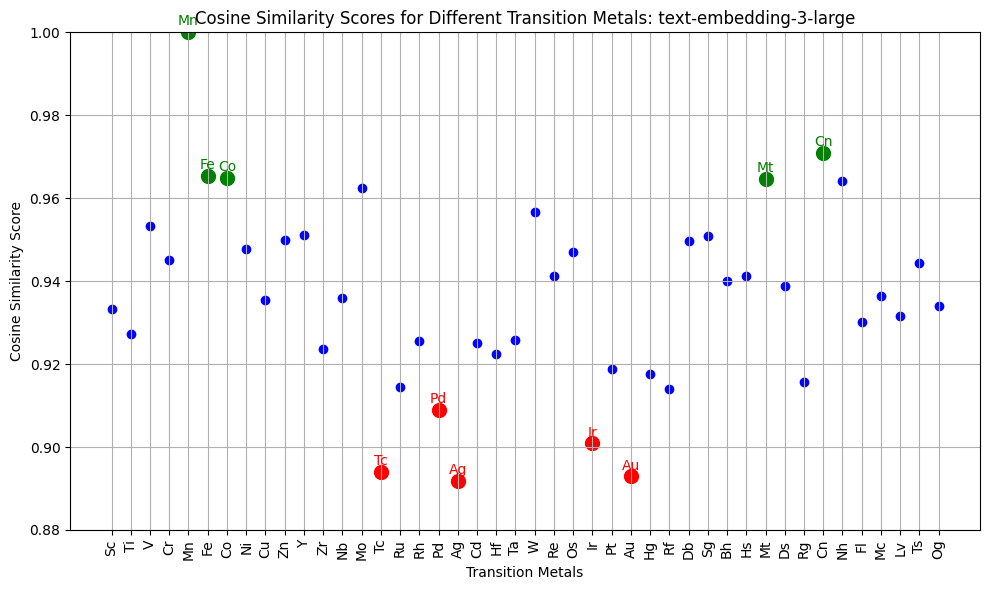

In [113]:
from openai import OpenAI
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

# Initialize OpenAI client
client = OpenAI()

# Configuration for the embedding model
model = "text-embedding-3-large"

# Function to generate embeddings in batches
def get_embeddings(texts, model=model):
    cleaned_texts = [text.replace("\n", " ") for text in texts]
    return client.embeddings.create(input=cleaned_texts, model=model).data

# Function to calculate cosine similarity between two embeddings
def cosine_sim(embedding1, embedding2):
    return cosine_similarity([embedding1], [embedding2])[0][0]

# Reference text example
reference_text = (
    "To synthesize Mn-CaWO4/SiO2, SiO2 (1.0 g) was impregnated with 4.5 mL of an aqueous solution consisting of Mn (0.247 mol), Ca (0.185 mol), W (0.185 mol), at 50 ºC for 6 h. "
    "Once activated the reaction is ran at 850 ºC. The total flow rate was 10 mL/min (Ar: 4.0 mL/min, CH4: 4.8 mL/min, O2: 1.2 mL/min), leading to a contact time of 0.75 s."
)
reference_embedding = get_embeddings([reference_text])[0].embedding

# List of transition metals
# transition_metals = [
#     "Ag",  # Silver
#     "Au",  # Gold
#     "Bh",  # Bohrium
#     "Cd",  # Cadmium
#     "Co",  # Cobalt
#     "Cr",  # Chromium
#     "Cu",  # Copper
#     "Db",  # Dubnium
#     "Ds",  # Darmstadtium
#     "Fe",  # Iron
#     "Fl",  # Flerovium
#     "Hf",  # Hafnium
#     "Hg",  # Mercury
#     "Hs",  # Hassium
#     "Ir",  # Iridium
#     "Lv",  # Livermorium
#     "Mc",  # Moscovium
#     "Mn",  # Manganese
#     "Mo",  # Molybdenum
#     "Mt",  # Meitnerium
#     "Nb",  # Niobium
#     "Ni",  # Nickel
#     "Nh",  # Nihonium
#     "Og",  # Oganesson
#     "Os",  # Osmium
#     "Pd",  # Palladium
#     "Pt",  # Platinum
#     "Rf",  # Rutherfordium
#     "Rh",  # Rhodium
#     "Rg",  # Roentgenium
#     "Ru",  # Ruthenium
#     "Sg",  # Seaborgium
#     "Sc",  # Scandium
#     "Ta",  # Tantalum
#     "Tc",  # Technetium
#     "Ti",  # Titanium
#     "Ts",  # Tennessine
#     "V",   # Vanadium
#     "W",   # Tungsten
#     "Y",   # Yttrium
#     "Zn",  # Zinc
#     "Zr"   # Zirconium
# ]

# transition_metals = [ # electronegativity
#     "Sc",  # Scandium
#     "Ti",  # Titanium
#     "V",   # Vanadium
#     "Cr",  # Chromium
#     "Mn",  # Manganese
#     "Fe",  # Iron
#     "Co",  # Cobalt
#     "Ni",  # Nickel
#     "Cu",  # Copper
#     "Zn",  # Zinc
#     "Y",   # Yttrium
#     "Zr",  # Zirconium
#     "Nb",  # Niobium
#     "Mo",  # Molybdenum
#     "Tc",  # Technetium
#     "Ru",  # Ruthenium
#     "Rh",  # Rhodium
#     "Pd",  # Palladium
#     "Ag",  # Silver
#     "Cd",  # Cadmium
#     "Hf",  # Hafnium
#     "Ta",  # Tantalum
#     "W",   # Tungsten
#     "Re",  # Rhenium
#     "Os",  # Osmium
#     "Ir",  # Iridium
#     "Pt",  # Platinum
#     "Au",  # Gold
#     "Hg",  # Mercury
#     "Rf",  # Rutherfordium
#     "Db",  # Dubnium
#     "Sg",  # Seaborgium
#     "Bh",  # Bohrium
#     "Hs",  # Hassium
#     "Mt",  # Meitnerium
#     "Ds",  # Darmstadtium
#     "Rg",  # Roentgenium
#     "Cn",  # Copernicium
#     "Nh",  # Nihonium
#     "Fl",  # Flerovium
#     "Mc",  # Moscovium
#     "Lv",  # Livermorium
#     "Ts",  # Tennessine
#     "Og"   # Oganesson
# ]

transition_metals = [
    "Sc",  # Scandium
    "Ti",  # Titanium
    "V",   # Vanadium
    "Cr",  # Chromium
    "Mn",  # Manganese
    "Fe",  # Iron
    "Co",  # Cobalt
    "Ni",  # Nickel
    "Cu",  # Copper
    "Zn",  # Zinc
    "Y",   # Yttrium
    "Zr",  # Zirconium
    "Nb",  # Niobium
    "Mo",  # Molybdenum
    "Tc",  # Technetium
    "Ru",  # Ruthenium
    "Rh",  # Rhodium
    "Pd",  # Palladium
    "Ag",  # Silver
    "Cd",  # Cadmium
    "Hf",  # Hafnium
    "Ta",  # Tantalum
    "W",   # Tungsten
    "Re",  # Rhenium
    "Os",  # Osmium
    "Ir",  # Iridium
    "Pt",  # Platinum
    "Au",  # Gold
    "Hg",  # Mercury
    "Rf",  # Rutherfordium
    "Db",  # Dubnium
    "Sg",  # Seaborgium
    "Bh",  # Bohrium
    "Hs",  # Hassium
    "Mt",  # Meitnerium
    "Ds",  # Darmstadtium
    "Rg",  # Roentgenium
    "Cn",  # Copernicium
    "Nh",  # Nihonium
    "Fl",  # Flerovium
    "Mc",  # Moscovium
    "Lv",  # Livermorium
    "Ts",  # Tennessine
    "Og"   # Oganesson
]


variations = [reference_text.replace("Mn-CaWO4", f"{metal}-CaWO4") for metal in transition_metals]
variation_embeddings = get_embeddings(variations)

scores = []
for metal, variation_embedding in zip(transition_metals, variation_embeddings):
    similarity_score = cosine_sim(reference_embedding, variation_embedding.embedding)
    scores.append(similarity_score)
    print(f"Element: {metal}, Cosine Similarity Score: {similarity_score}")

scores_array = np.array(scores)
metals_array = np.array(transition_metals)
lowest_indices = np.argsort(scores_array)[:5]
highest_indices = np.argsort(scores_array)[-5:]

plt.figure(figsize=(10, 6))
plt.scatter(metals_array, scores_array, color="blue")
plt.xlabel("Transition Metals")
plt.ylabel("Cosine Similarity Score")
plt.ylim(0.88, 1.0)
plt.title(f'Cosine Similarity Scores for Different Transition Metals: {model}')
plt.xticks(rotation=90)
plt.grid(True)

def annotate_points(indices, color):
    for idx in indices:
        plt.scatter(metals_array[idx], scores_array[idx], color=color, s=100)
        plt.annotate(f'{metals_array[idx]}',
                     (metals_array[idx], scores_array[idx]),
                     textcoords="offset points",
                     xytext=(0, 5),  # Offset for visibility
                     ha='center',
                     color=color)

annotate_points(lowest_indices, 'red')
annotate_points(highest_indices, 'green')

plt.tight_layout()
plt.show()

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.metrics.pairwise import cosine_similarity
# from tqdm import tqdm
# from openai import OpenAI
# client = OpenAI()

model = "text-embedding-3-large"

def get_embeddings(texts, model=model, batch_size=100):
    all_embeddings = []
    cleaned_texts = [text.replace("\n", " ") if isinstance(text, str) else "" for text in texts]
    for i in range(0, len(cleaned_texts), batch_size):
        batch = cleaned_texts[i: i + batch_size]
        embeddings_data = client.embeddings.create(input=batch, model=model).data
        all_embeddings.extend([embedding.embedding for embedding in embeddings_data])
    return np.array(all_embeddings)

small_data_path = "/Users/shane/repos/BO-LIFT/paper/dataset/data/bias_free_ocmdataset_p_comp.csv"  # Replace with the path to the 300-point dataset
large_data_path = "/Users/shane/repos/BO-LIFT/paper/dataset/data/C2_yield_meth_oxy_short_corrected.csv"  # Replace with the path to the 1200-point dataset
small_data = pd.read_csv(small_data_path)
large_data = pd.read_csv(large_data_path)

prompt_col = "prompt"
completion_col = "completion"
small_prompts = small_data[prompt_col].fillna("").tolist()
large_prompts = large_data[prompt_col].fillna("").tolist()
small_embeddings = get_embeddings(small_prompts)
large_embeddings = get_embeddings(large_prompts)

similarities = cosine_similarity(small_embeddings, large_embeddings)
selected_indices = set()
new_data_list = []

for i, small_prompt in tqdm(enumerate(small_prompts), total=len(small_prompts)):

    # Get indices sorted by similarity in descending order
    sorted_indices = np.argsort(similarities[i])[::-1]

    count = 0
    for index in sorted_indices:
        if index not in selected_indices:
            # Retrieve the prompt and completion from the larger dataset
            large_prompt = large_data.iloc[index][prompt_col]
            completion_text = large_data.iloc[index][completion_col]
            new_data_list.append({"prompt": large_prompt, "completion": completion_text})
            selected_indices.add(index)
            count += 1
        if count == 10:
            break

new_data = pd.DataFrame(new_data_list)
new_data.to_csv("top_10_similar_subset.csv", index=False)


100%|██████████| 291/291 [00:00<00:00, 973.36it/s]


     mode      model  surface_noise  chem_signal    snr  unit_sens  gas_rank
      RAW    ada-002         0.0003       0.0011 3.4028     0.4026         1
      RAW    3-large         0.0021       0.0032 1.4835     0.7935         5
      RAW matscibert         0.0007       0.0017 2.3093     0.5608         5
PROJ_ref1    ada-002         0.2078       0.5208 2.5059     0.4182         2
PROJ_ref1    3-large         0.4015       0.5274 1.3136     0.7877         7
PROJ_ref1 matscibert         0.2268       0.4548 2.0053     0.6122         6
PROJ_ref2    ada-002         0.2130       0.5279 2.4791     0.4218         2
PROJ_ref2    3-large         0.2415       0.3445 1.4263     0.7441         7
PROJ_ref2 matscibert         0.1921       0.3793 1.9744     0.6371         6
PROJ_both    ada-002         0.2456       0.5920 2.4103     0.4252         3
PROJ_both    3-large         0.3480       0.4714 1.3547     0.7591         7
PROJ_both matscibert         0.2293       0.4501 1.9634     0.6303         6

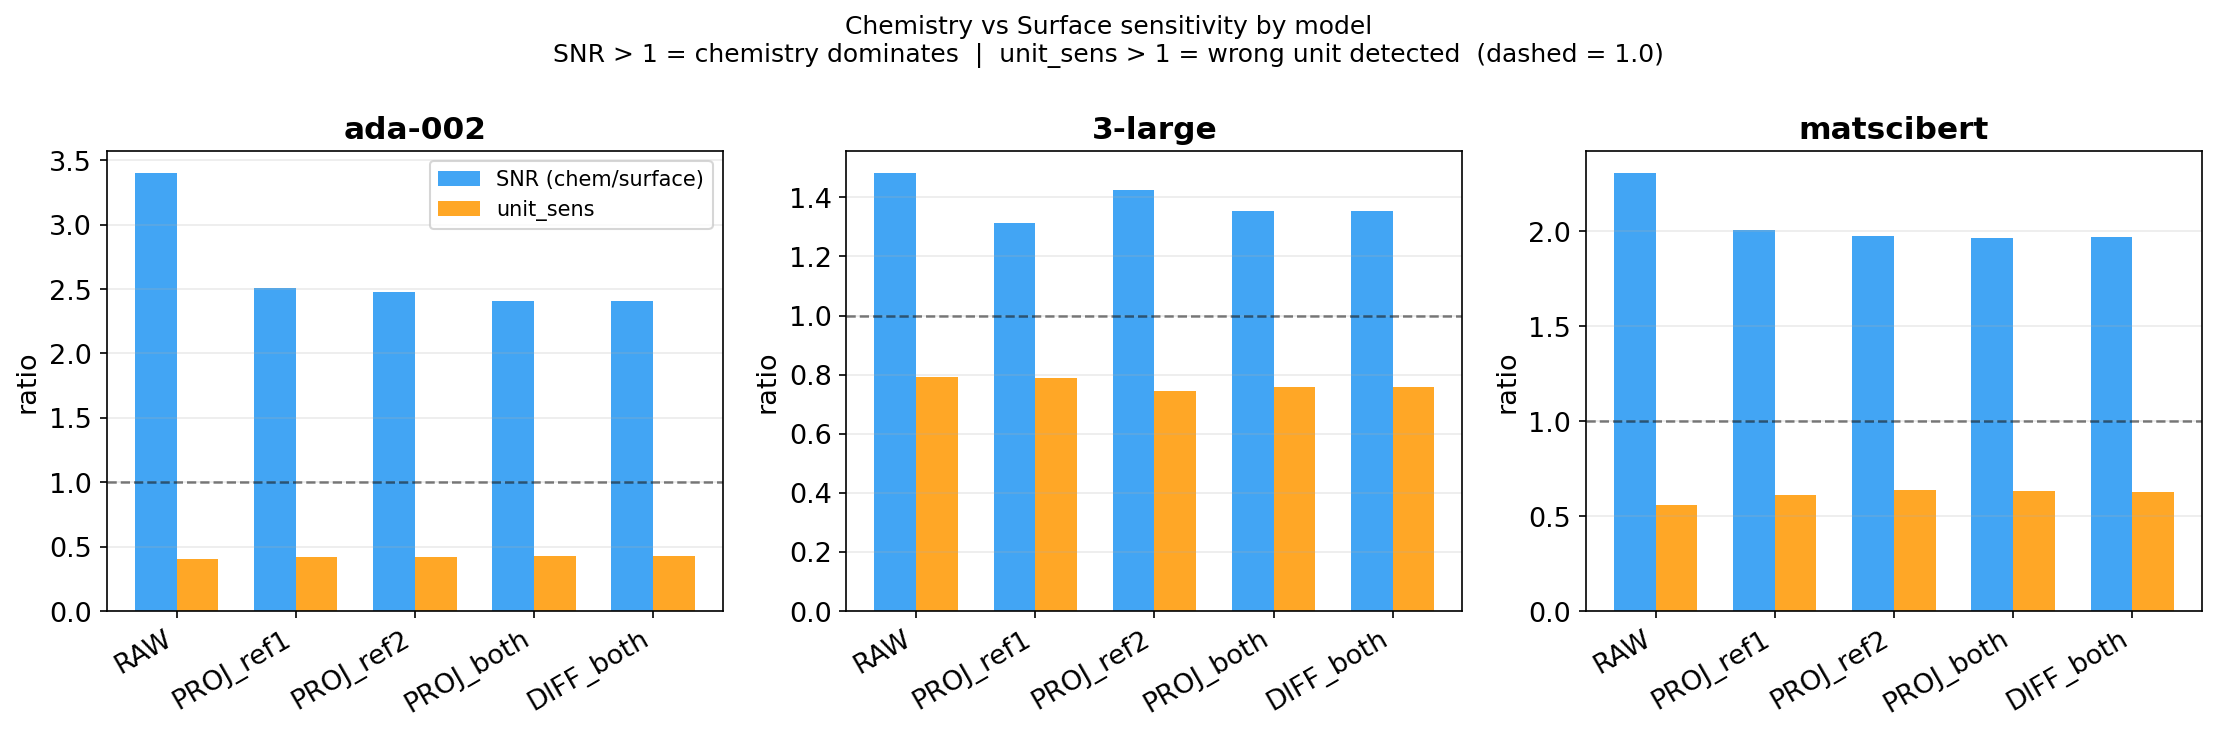

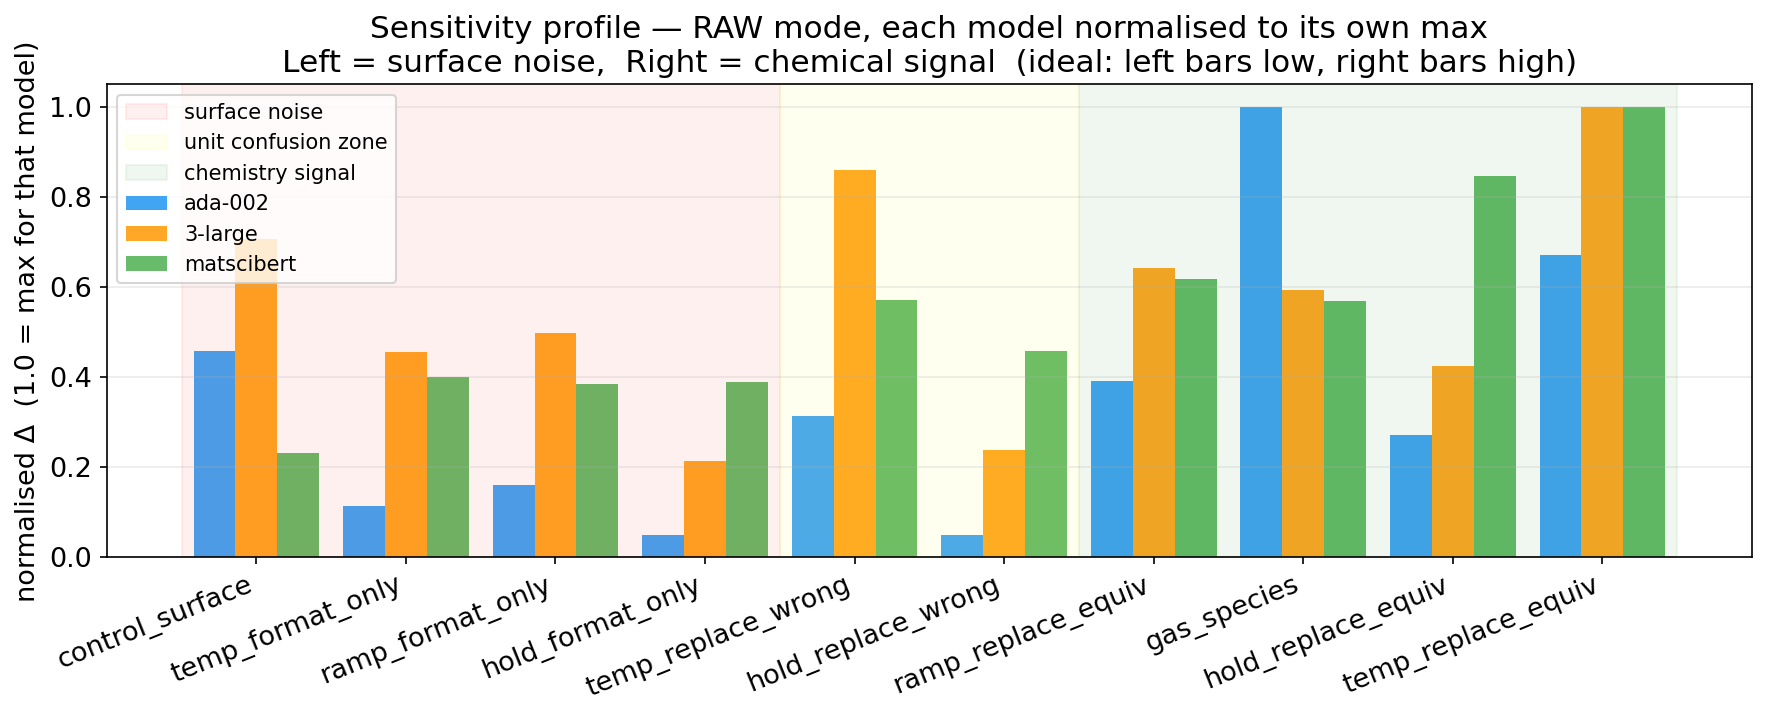

/var/folders/gn/t7lkvwjx45l9y1jzv5lphf2h0000gn/T/ipykernel_54340/3233673772.py:188: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


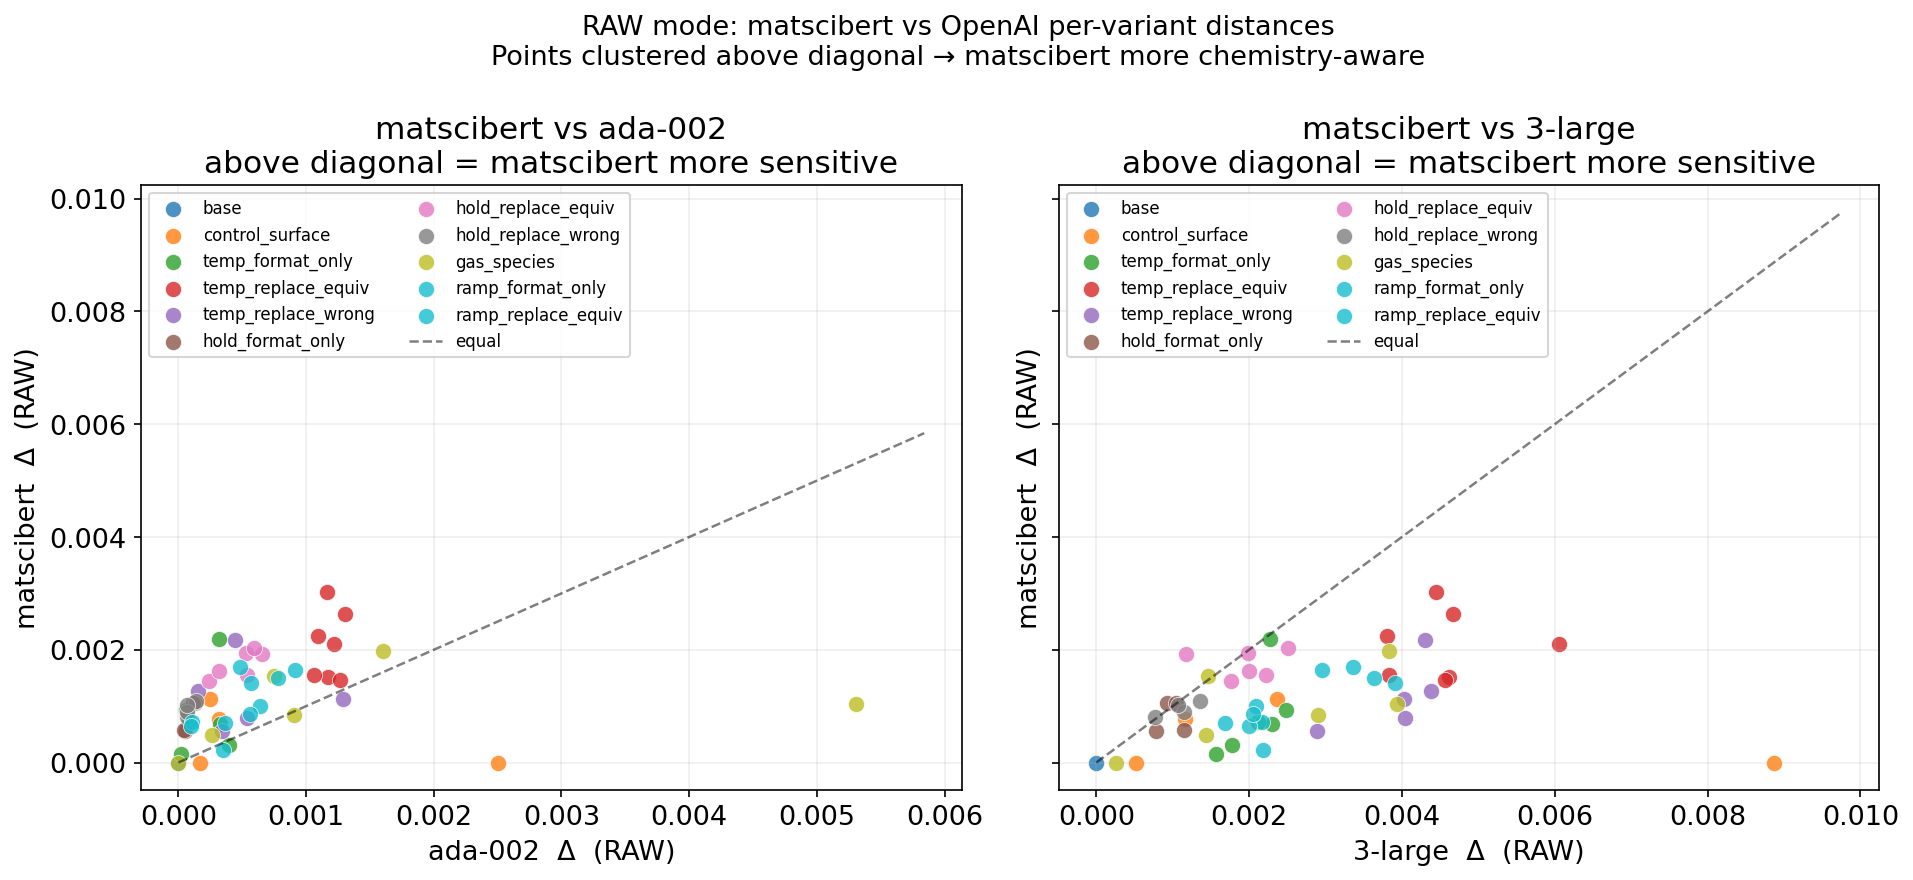


RECOMMENDATION SUMMARY

ada-002
  SNR (chem/surface):  3.40  ✅ chemistry > surface
  unit_sens:           0.40  ❌ wrong units invisible
  gas_species rank:    1/10  ✅

3-large
  SNR (chem/surface):  1.48  ✅ chemistry > surface
  unit_sens:           0.79  ❌ wrong units invisible
  gas_species rank:    5/10  ⚠️ 

matscibert
  SNR (chem/surface):  2.31  ✅ chemistry > surface
  unit_sens:           0.56  ❌ wrong units invisible
  gas_species rank:    5/10  ⚠️ 

For BO pool search (bert_ask_tell.py):
  The best model should have high SNR, unit_sens > 1, and gas_species
  ranked in the top 3.  All RAW deltas are ~1e-3, so the embedding space
  is dense — consider fine-tuning or a contrastive objective on your
  dataset as a longer-term fix regardless of which model you choose.



In [6]:
"""
analyze_model_fit.py
====================
Reads scores_bert_comparison.csv and answers:
  "Which model focuses on chemistry vs surface text, 
   and which is best for the BO pool-search task?"

Three metrics per model × mode
-------------------------------
  SNR          mean(chemistry_signal) / mean(surface_noise)
               > 1 means the model responds more to real chemical changes
               than to formatting noise — higher is better for BO

  unit_sens    mean(wrong_unit_Δ) / mean(equiv_unit_Δ)
               < 1 means the model thinks "3.92 min" is MORE similar to 
               "3.92 hr" than "235.2 min" is (bad — numeracy failure)
               > 1 is ideal

  gas_rank     where gas_species sits in the group ranking (1 = highest Δ)
               lower rank = model treats gas identity as the biggest signal

Group definitions
-----------------
  surface_noise:      control_surface, temp_format_only, 
                      hold_format_only, ramp_format_only
  chemistry_signal:   gas_species, temp_replace_equiv, hold_replace_equiv
  wrong_unit:         temp_replace_wrong, hold_replace_wrong
  equiv_unit:         temp_replace_equiv, hold_replace_equiv
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.size": 14, "axes.titlesize": 15,
    "axes.labelsize": 13, "legend.fontsize": 12,
})

OUTDIR = "figures_bert"
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv("scores_bert_comparison.csv")

# ── Group definitions ─────────────────────────────────────────────────────────

SURFACE_NOISE    = ["control_surface", "temp_format_only",
                    "hold_format_only", "ramp_format_only"]
CHEM_SIGNAL      = ["gas_species", "temp_replace_equiv", "hold_replace_equiv"]
WRONG_UNIT       = ["temp_replace_wrong", "hold_replace_wrong"]
EQUIV_UNIT       = ["temp_replace_equiv", "hold_replace_equiv"]

ALL_GROUPS_ORDERED = [
    "control_surface", "temp_format_only", "ramp_format_only",
    "hold_format_only", "temp_replace_wrong", "hold_replace_wrong",
    "ramp_replace_equiv", "gas_species", "hold_replace_equiv",
    "temp_replace_equiv",
]

MODELS = df["model"].unique().tolist()
MODES  = df["mode"].unique().tolist()

# ── Compute metrics ───────────────────────────────────────────────────────────

def group_mean(sub, groups, excl_baseline=False):
    rows = sub[sub["group"].isin(groups)]
    if excl_baseline:
        rows = rows[rows["note"] != "baseline"]
    return rows["delta"].mean()

records = []
for mode in MODES:
    dm = df[df["mode"] == mode]
    for model in MODELS:
        m = dm[dm["model"] == model]

        surface = group_mean(m, SURFACE_NOISE)
        chem    = group_mean(m, CHEM_SIGNAL, excl_baseline=True)
        wrong   = group_mean(m, WRONG_UNIT)
        equiv   = group_mean(m, EQUIV_UNIT)

        snr          = chem / surface if surface > 0 else np.nan
        unit_sens    = wrong / equiv  if equiv > 0  else np.nan

        # rank of gas_species mean among all groups (1 = highest Δ)
        group_means = {}
        for g in ALL_GROUPS_ORDERED:
            sub = m[m["group"] == g]
            if g == "gas_species":
                sub = sub[sub["note"] != "baseline"]
            group_means[g] = sub["delta"].mean()
        sorted_groups = sorted(group_means, key=group_means.get, reverse=True)
        gas_rank = sorted_groups.index("gas_species") + 1

        records.append(dict(mode=mode, model=model,
                            surface_noise=surface, chem_signal=chem,
                            snr=snr, unit_sens=unit_sens,
                            gas_rank=gas_rank))

metrics = pd.DataFrame(records)
print(metrics.to_string(index=False, float_format="{:.4f}".format))

# ── Figure 1: SNR and unit_sens across modes, one panel per model ─────────────

fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 5), sharey=False)
if len(MODELS) == 1:
    axes = [axes]

x    = np.arange(len(MODES))
w    = 0.35
cols = {"SNR": "#2196F3", "unit_sens": "#FF9800"}

for ax, model in zip(axes, MODELS):
    sub  = metrics[metrics["model"] == model].set_index("mode")
    snrs = [sub.loc[m, "snr"]       for m in MODES]
    unis = [sub.loc[m, "unit_sens"] for m in MODES]

    ax.bar(x - w/2, snrs, w, label="SNR (chem/surface)", color=cols["SNR"],   alpha=0.85)
    ax.bar(x + w/2, unis, w, label="unit_sens",          color=cols["unit_sens"], alpha=0.85)
    ax.axhline(1.0, color="k", linewidth=1.2, linestyle="--", alpha=0.5)
    ax.set_title(model, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(MODES, rotation=30, ha="right")
    ax.set_ylabel("ratio"); ax.grid(axis="y", alpha=0.25)
    if ax == axes[0]:
        ax.legend(loc="upper right", fontsize=10)

fig.suptitle("Chemistry vs Surface sensitivity by model\n"
             "SNR > 1 = chemistry dominates  |  unit_sens > 1 = wrong unit detected  "
             "(dashed = 1.0)",
             fontsize=12)
plt.tight_layout()
for ext in ("png", "pdf"):
    plt.savefig(os.path.join(OUTDIR, f"model_fit_snr.{ext}"), bbox_inches="tight")
plt.show()
plt.close()

# ── Figure 2: Group-level sensitivity profile (RAW mode, normalised) ──────────
# Shows the "fingerprint" of each model — what kinds of changes does it notice?

raw = df[df["mode"] == "RAW"]
fig, ax = plt.subplots(figsize=(12, 5))

bar_w = 0.28
x     = np.arange(len(ALL_GROUPS_ORDERED))
model_colors = {"ada-002": "#2196F3", "3-large": "#FF9800", "matscibert": "#4CAF50"}

for i, model in enumerate(MODELS):
    m = raw[raw["model"] == model]
    # normalise each model to its own max so profiles are comparable shape
    means = []
    for g in ALL_GROUPS_ORDERED:
        sub = m[m["group"] == g]
        if g == "gas_species": sub = sub[sub["note"] != "baseline"]
        means.append(sub["delta"].mean())
    means = np.array(means)
    means_norm = means / means.max()
    offs = x + (i - (len(MODELS)-1)/2) * bar_w
    ax.bar(offs, means_norm, bar_w,
           label=model, color=model_colors.get(model), alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(ALL_GROUPS_ORDERED, rotation=22, ha="right")
ax.set_ylabel("normalised Δ  (1.0 = max for that model)")
ax.set_title("Sensitivity profile — RAW mode, each model normalised to its own max\n"
             "Left = surface noise,  Right = chemical signal  "
             "(ideal: left bars low, right bars high)")
ax.axvspan(-0.5, 3.5,  alpha=0.06, color="red",   label="surface noise")
ax.axvspan(3.5,  5.5,  alpha=0.06, color="yellow", label="unit confusion zone")
ax.axvspan(5.5,  9.5,  alpha=0.06, color="green",  label="chemistry signal")
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
for ext in ("png", "pdf"):
    plt.savefig(os.path.join(OUTDIR, f"model_fit_profile.{ext}"), bbox_inches="tight")
plt.show()
plt.close()

# ── Figure 3: Head-to-head RAW scatter, matscibert vs each OpenAI ─────────────
# Points above the diagonal = matscibert sees more difference

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
raw_bert = (raw[raw["model"] == "matscibert"]
            .set_index("label")["delta"].rename("bert"))
grp_map  = raw[["label","group"]].drop_duplicates().set_index("label")["group"]

cmap = plt.cm.get_cmap("tab10")
all_groups = raw["group"].unique()
color_map  = {g: cmap(i) for i, g in enumerate(all_groups)}

for ax, oai in zip(axes, ["ada-002", "3-large"]):
    oai_s = (raw[raw["model"] == oai]
             .set_index("label")["delta"].rename("oai"))
    mrg   = pd.concat([raw_bert, oai_s], axis=1).dropna()
    mrg["group"] = mrg.index.map(grp_map)

    for g in mrg["group"].unique():
        sub = mrg[mrg["group"] == g]
        ax.scatter(sub["oai"], sub["bert"], label=g,
                   color=color_map[g], alpha=0.8, s=60,
                   edgecolors="white", linewidths=0.4)

    lim = max(mrg["oai"].max(), mrg["bert"].max()) * 1.1
    ax.plot([0, lim], [0, lim], "k--", lw=1.2, alpha=0.5, label="equal")
    ax.set_xlabel(f"{oai}  Δ  (RAW)")
    ax.set_ylabel("matscibert  Δ  (RAW)")
    ax.set_title(f"matscibert vs {oai}\n"
                 "above diagonal = matscibert more sensitive")
    ax.legend(fontsize=8, ncol=2, loc="upper left")
    ax.grid(alpha=0.2)

fig.suptitle("RAW mode: matscibert vs OpenAI per-variant distances\n"
             "Points clustered above diagonal → matscibert more chemistry-aware",
             fontsize=13)
plt.tight_layout()
for ext in ("png", "pdf"):
    plt.savefig(os.path.join(OUTDIR, f"model_fit_scatter.{ext}"), bbox_inches="tight")
plt.show()
plt.close()

# ── Print recommendation ──────────────────────────────────────────────────────

print("\n" + "="*65)
print("RECOMMENDATION SUMMARY")
print("="*65)

raw_m = metrics[metrics["mode"] == "RAW"].set_index("model")

for model in MODELS:
    r = raw_m.loc[model]
    print(f"\n{model}")
    print(f"  SNR (chem/surface):  {r['snr']:.2f}  "
          f"{'✅ chemistry > surface' if r['snr'] > 1 else '❌ surface dominates'}")
    print(f"  unit_sens:           {r['unit_sens']:.2f}  "
          f"{'✅ wrong units detected' if r['unit_sens'] > 1 else '❌ wrong units invisible'}")
    print(f"  gas_species rank:    {int(r['gas_rank'])}/10  "
          f"{'✅' if r['gas_rank'] <= 3 else '⚠️ '}")

print("""
For BO pool search (bert_ask_tell.py):
  The best model should have high SNR, unit_sens > 1, and gas_species
  ranked in the top 3.  All RAW deltas are ~1e-3, so the embedding space
  is dense — consider fine-tuning or a contrastive objective on your
  dataset as a longer-term fix regardless of which model you choose.
""")

=== Variants per group ===
group
base                  1
control_surface       4
gas_species           6
hold_format_only      4
hold_replace_equiv    6
hold_replace_wrong    4
ramp_format_only      5
ramp_replace_equiv    5
temp_format_only      6
temp_replace_equiv    7
temp_replace_wrong    5

[Embedding] ada-002

[Embedding] 3-large

[Embedding] matbert
[MatBERT] dataset NPZ: 2,500 entries  dim=768
[MatBERT] variant NPZ: 153 entries  first key='BASE (reference)'
  [MatBERT] all 56 from cache

All embeddings complete.
Saved: scores_bert_comparison.csv  |  swap_table_bert_comparison.csv

=== Trend summary ===

MODE: RAW

  ada-002
    meanΔ[control_surface             ] = 0.000808  (n=4)
    meanΔ[temp_format_only            ] = 0.000203  (n=6)
    meanΔ[temp_replace_equiv          ] = 0.001189  (n=7)
    meanΔ[temp_replace_wrong          ] = 0.000556  (n=5)
    meanΔ[hold_format_only            ] = 0.000089  (n=4)
    meanΔ[hold_replace_equiv          ] = 0.000480  (n=6)
    meanΔ[h

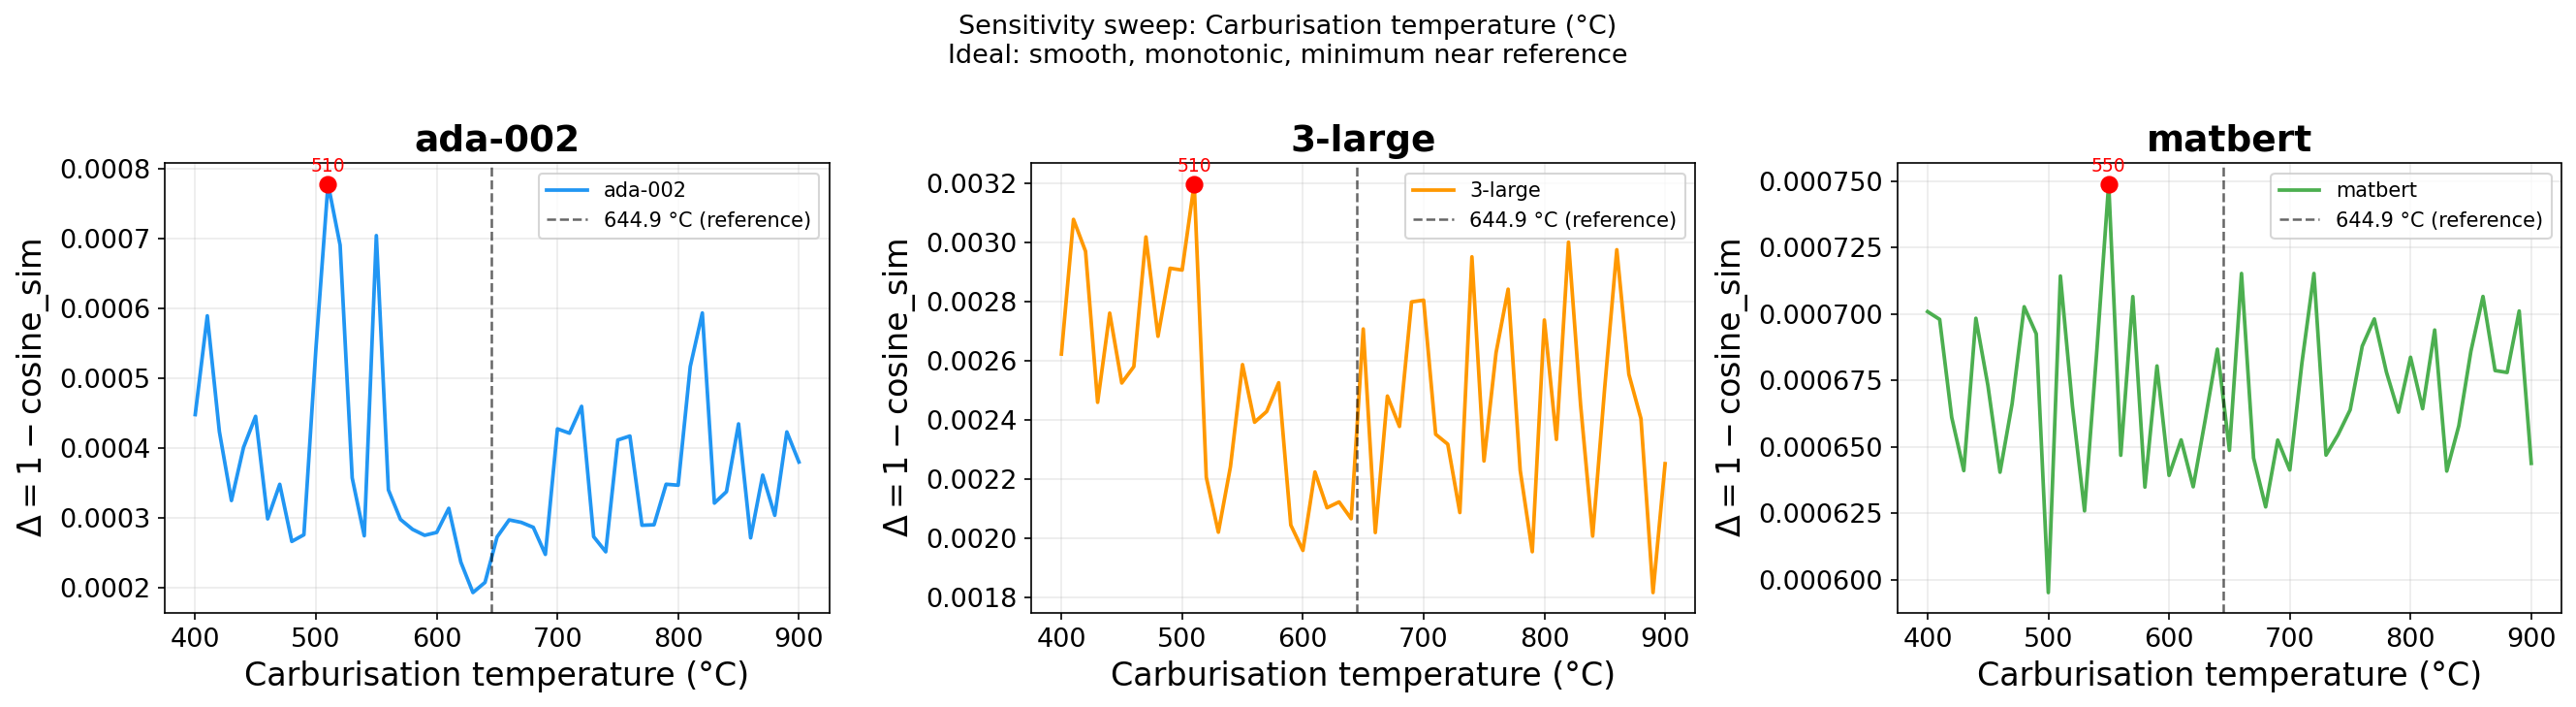

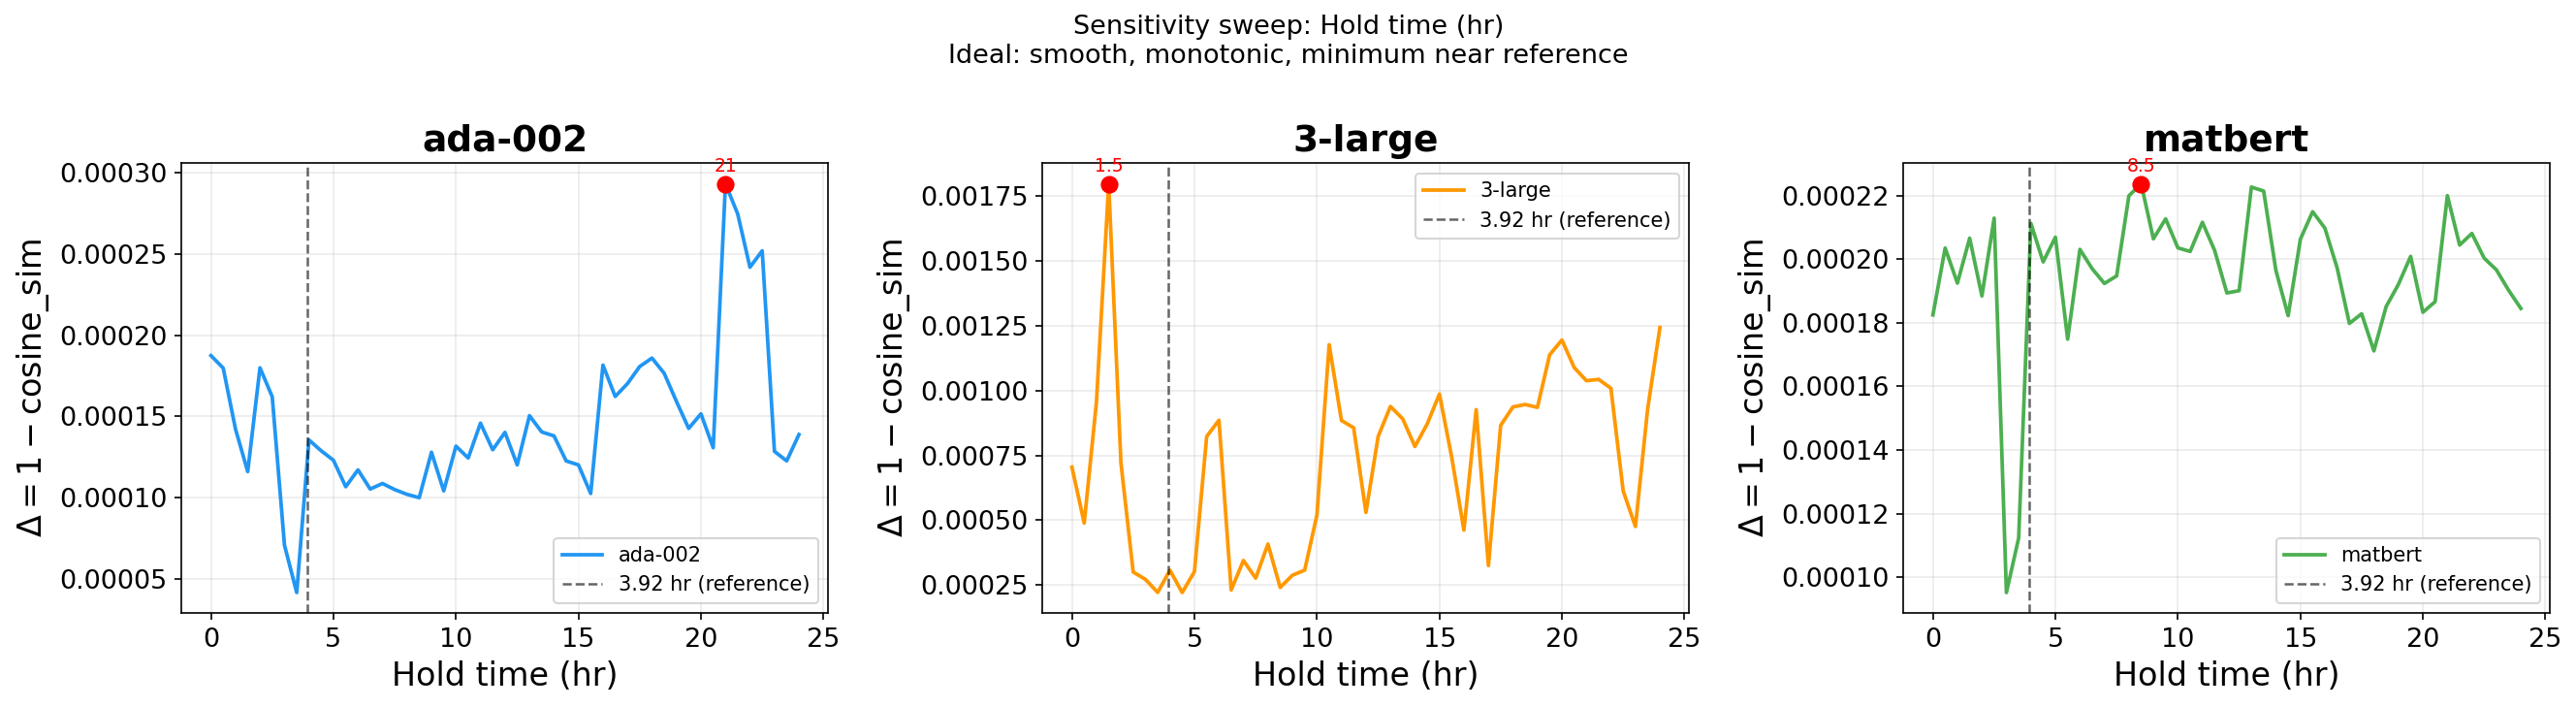

  Saved: figures_bert/sweeps/temperature_sweep_overlay.png
  Saved: figures_bert/sweeps/temperature_sweep_overlay.pdf


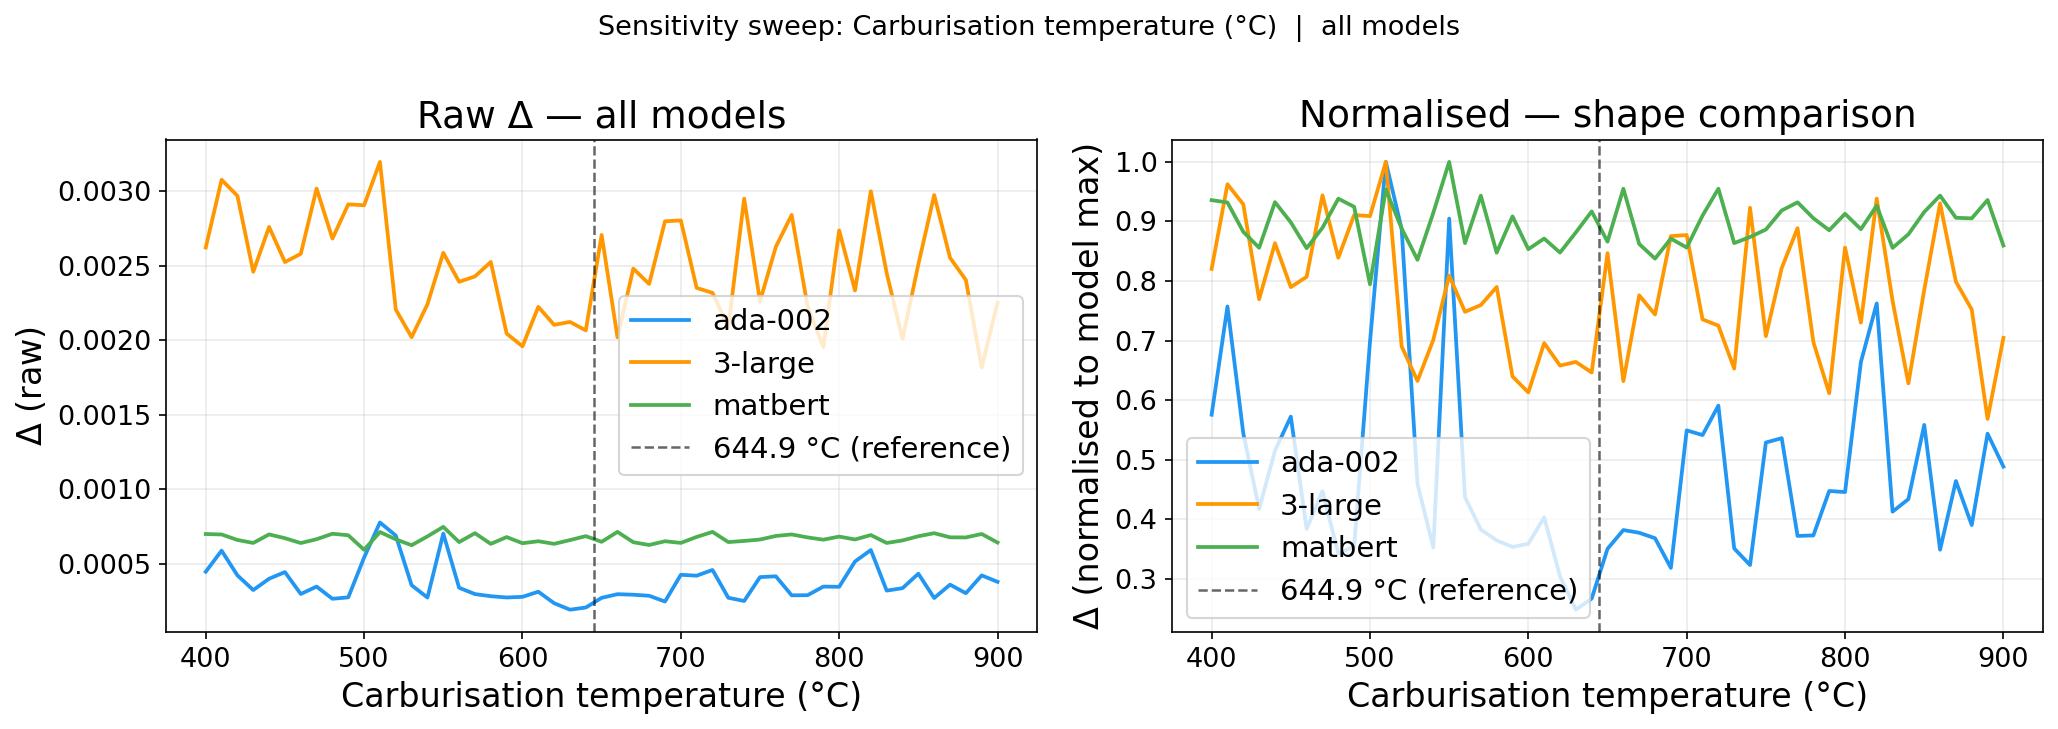

  Saved: figures_bert/sweeps/hold_time_sweep_overlay.png
  Saved: figures_bert/sweeps/hold_time_sweep_overlay.pdf


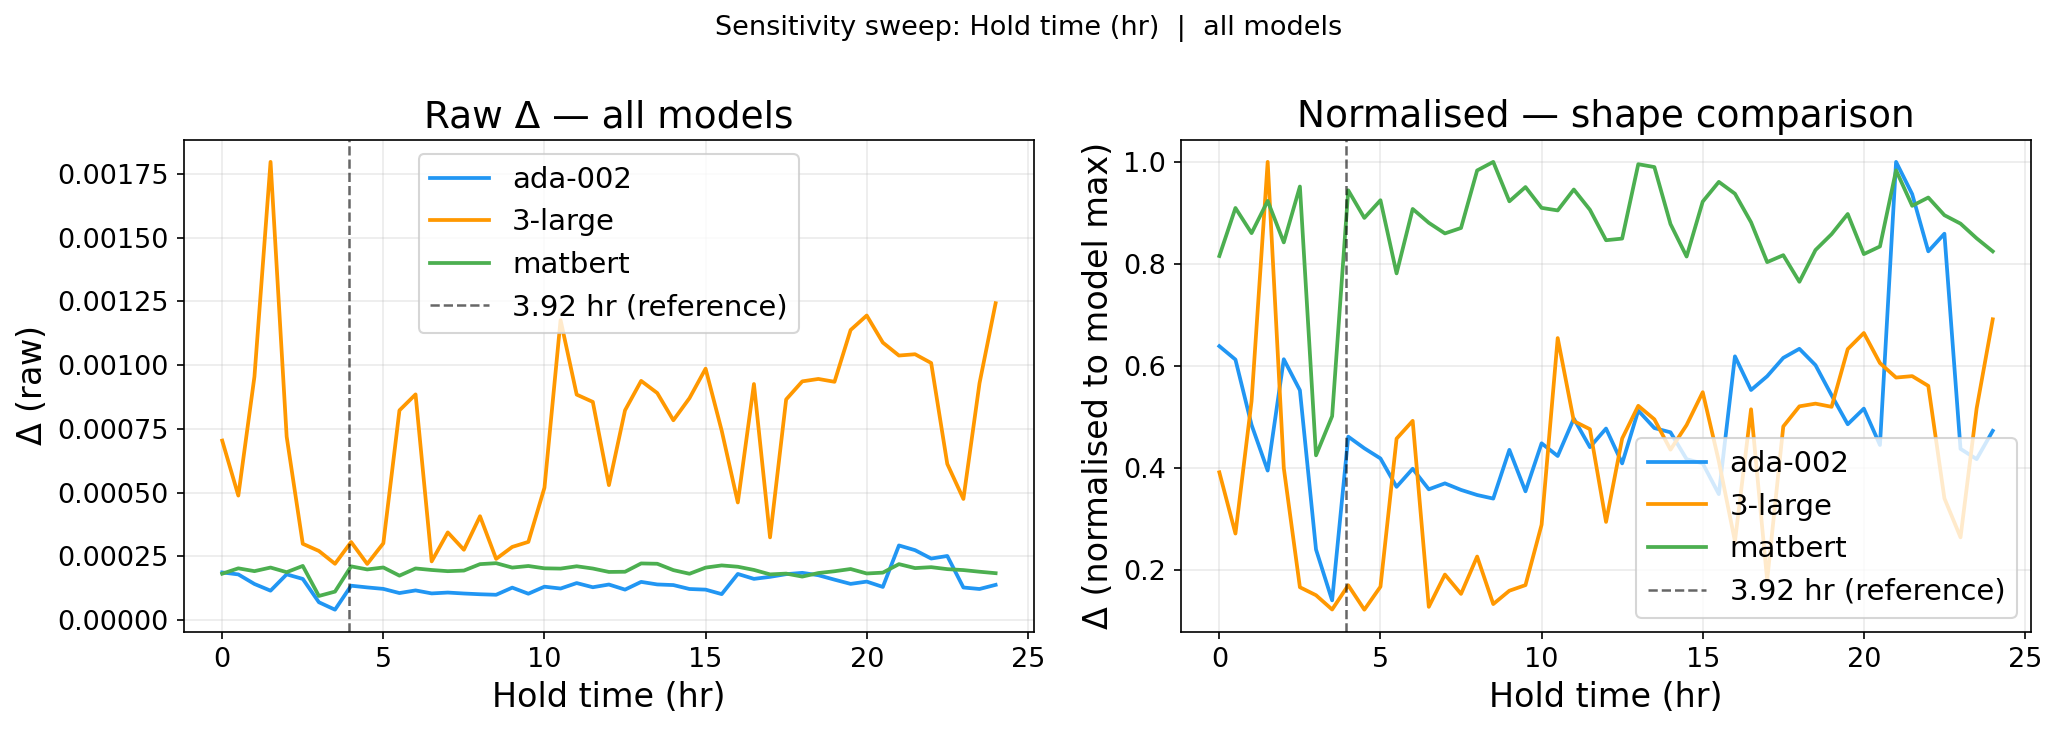


Sweep results in figures_bert/sweeps/ and *_sweep.csv


In [4]:
# ============================================================
# eval_embeddings_bert_comparison.py
# ============================================================
# Compares three embedding models on Mo-carburization procedures:
#   - OpenAI text-embedding-ada-002
#   - OpenAI text-embedding-3-large
#   - MatBERT  (fully cache-based — no live model needed)
#
# MatBERT requires TWO pre-computed NPZ files generated by
# matbert_embed_colab.py (run once in Colab):
#   NPZ_PATH         dataset procedures (2500 rows)
#   NPZ_VARIANTS_PATH  eval variants + sweep texts (~150 strings)
#
# All MatBERT lookups are cache-only. No local checkpoint needed.
#
# Scoring modes (post-hoc vector operations, not string concatenation)
# -------------
#   RAW        cosine(ref, var)
#   PROJ_ref1  project out new_ref1 direction, then cosine
#   PROJ_ref2  project out new_ref2 direction, then cosine
#   PROJ_both  project out mean(ref1, ref2) direction, then cosine
#   DIFF_both  subtract mean(ref1, ref2) from both, then cosine
#
# Outputs: scores_bert_comparison.csv  |  swap_table_bert_comparison.csv
#          figures_bert/<mode>/<name>.{png,pdf}
#          figures_bert/sweeps/<name>.{png,pdf}
# ============================================================

from __future__ import annotations
import os, re, unicodedata, warnings
from typing import Dict, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

NPZ_PATH          = "/Users/shane/repos/boicl_crystal_phase_isolation/matbert_embeddings (3).npz"
NPZ_VARIANTS_PATH = "/Users/shane/repos/boicl_crystal_phase_isolation/matbert_variant_embeddings (3).npz"
BERT_BATCH_SIZE   = 32   # unused unless live fallback triggers
BERT_DEVICE: Optional[str] = None

OPENAI_MODELS = {
    "ada-002": "text-embedding-ada-002",
    "3-large": "text-embedding-3-large",
}
ALL_MODELS    = list(OPENAI_MODELS) + ["matbert"]
N_NOISE_DUPES = 16
OUTDIR        = "figures_bert"
os.makedirs(OUTDIR, exist_ok=True)

openai_client = OpenAI()

plt.rcParams.update({
    "figure.figsize": (13.33, 7.5), "figure.dpi": 150, "savefig.dpi": 300,
    "font.size": 16, "axes.titlesize": 18, "axes.labelsize": 16,
    "xtick.labelsize": 13, "ytick.labelsize": 13, "legend.fontsize": 14,
})

# ── REFERENCE & CONTEXT PROCEDURES  (all real dataset entries) ───────────────
reference_text = (
    "Dissolve 1 g ammonium heptamolybdate tetrahydrate in 6 mL DI water. "
    "Dissolve 1 g sucrose in 1.5 mL DI water. "
    "Combine; stir 15 min at 300 RPM; dry at 120 °C in air for 24 hr. "
    "Crush. Load 1 g into crucible; ramp 15 °C/min to 644.9 °C, hold 3.92 hr under 30 ccm H2. "
    "Cool under 30 ccm N2 to <30 °C. "
    "Passivate under 30 ccm 1% O2/N2 for 2 hr."
)
new_ref1 = (
    "Dissolve 1 g ammonium heptamolybdate tetrahydrate in 6 mL DI water. "
    "Dissolve 1 g sucrose in 1.5 mL DI water. "
    "Combine; stir 15 min at 300 RPM; dry at 120 °C in air for 24 hr. "
    "Crush. Load 1 g into crucible; ramp 15 °C/min to 491.8 °C, hold 24.00 hr under 30 ccm H2. "
    "Cool under 30 ccm N2 to <30 °C. "
    "Passivate under 30 ccm 1% O2/N2 for 2 hr."
)
new_ref2 = (
    "Dissolve 1 g ammonium heptamolybdate tetrahydrate in 6 mL DI water. "
    "Dissolve 1 g sucrose in 1.5 mL DI water. "
    "Combine; stir 15 min at 300 RPM; dry at 120 °C in air for 24 hr. "
    "Crush. Load 1 g into crucible; ramp 15 °C/min to 798.0 °C, hold 24.00 hr under 30 ccm H2. "
    "Cool under 30 ccm N2 to <30 °C. "
    "Passivate under 30 ccm 1% O2/N2 for 2 hr."
)

T_REF, H_REF = 644.9, 3.92
T_K   = T_REF + 273.15
T_F   = T_REF * 9/5 + 32
H_MIN = H_REF * 60
H_S   = int(H_MIN * 60)

# ── SCORING MODES ─────────────────────────────────────────────────────────────

def _l2(v):
    return v / (np.linalg.norm(v) + 1e-12)

def _project_out(vec, axis):
    a = _l2(axis)
    return vec - np.dot(vec, a) * a

def cosine_sim(a, b):
    return float(sk_cosine([a], [b])[0][0])

def score_raw(ref_v, var_v, ctx_vecs):
    return cosine_sim(ref_v, var_v)

def score_proj(ref_v, var_v, ctx_vecs):
    axis = np.mean(ctx_vecs, axis=0)
    return cosine_sim(_project_out(ref_v, axis), _project_out(var_v, axis))

def score_diff(ref_v, var_v, ctx_vecs):
    bg = np.mean(ctx_vecs, axis=0)
    return cosine_sim(ref_v - bg, var_v - bg)

SCORE_MODES: Dict[str, dict] = {
    "RAW":        dict(fn=score_raw,  ctx_keys=[]),
    "PROJ_ref1":  dict(fn=score_proj, ctx_keys=["new_ref1"]),
    "PROJ_ref2":  dict(fn=score_proj, ctx_keys=["new_ref2"]),
    "PROJ_both":  dict(fn=score_proj, ctx_keys=["new_ref1", "new_ref2"]),
    "DIFF_both":  dict(fn=score_diff, ctx_keys=["new_ref1", "new_ref2"]),
}
PLOT_MODES = list(SCORE_MODES)

# ── HELPERS ───────────────────────────────────────────────────────────────────

def canonicalize(t: str) -> str:
    return unicodedata.normalize("NFC", t.replace("\n", " "))

def _sub1(text, pat, repl, tag):
    out, n = re.subn(pat, repl, text)
    if n != 1:
        raise ValueError(f"[{tag}] expected 1 match; got {n}")
    return out

def replace_temp(text, repl):
    return _sub1(text, r"(ramp 15 °C/min to)\s*644\.9\s*°C", rf"\1 {repl}", "temp")
def replace_hold(text, repl):
    return _sub1(text, r"(hold)\s*3\.92\s*hr", rf"\1 {repl}", "hold")
def replace_gas(text, g):
    return _sub1(text, r"(hold \S+ hr under 30 ccm\s+)H2\b", rf"\g<1>{g}", "gas")
def replace_ramp(text, repl):
    return _sub1(text, r"ramp 15 °C/min", f"ramp {repl}", "ramp")

def group_stats(v):
    v = np.asarray(v, dtype=float)
    if not len(v):
        return dict(mean=np.nan, q25=np.nan, q75=np.nan, n=0)
    return dict(mean=float(v.mean()), q25=float(np.quantile(v, .25)),
                q75=float(np.quantile(v, .75)), n=int(len(v)))

def icon(ok): return "✅" if ok else "❌"

def save_fig(name, mode=None):
    d = os.path.join(OUTDIR, mode) if mode else OUTDIR
    os.makedirs(d, exist_ok=True)
    for ext in ("png", "pdf"):
        p = os.path.join(d, f"{name}.{ext}")
        plt.savefig(p, bbox_inches="tight")
        print(f"  {p}")

# ── OPENAI EMBEDDER ───────────────────────────────────────────────────────────

def embed_openai(texts: List[str], model_name: str) -> List[np.ndarray]:
    texts = [canonicalize(t) for t in texts]
    resp  = openai_client.embeddings.create(model=model_name, input=texts)
    return [np.array(d.embedding) for d in sorted(resp.data, key=lambda d: d.index)]

# ── MATBERT EMBEDDER  (cache-only, no live model) ────────────────────────────
#
# Dataset NPZ  → keyed by procedure text  (reference, new_ref1, new_ref2)
# Variant NPZ  → keyed by variant label   ("BASE (reference)", "Control: double-space", …)
#
# embed_labeled(texts, labels) tries text cache first, then label cache.

class HybridBertEmbedder:

    def __init__(self, npz_path: Optional[str],
                 npz_variants_path: Optional[str] = None,
                 **_ignored) -> None:
        self._text_cache:  Dict[str, np.ndarray] = {}   # text  → vec  (dataset NPZ)
        self._label_cache: Dict[str, np.ndarray] = {}   # label → vec  (variant NPZ)

        if npz_path and os.path.exists(npz_path):
            data  = np.load(npz_path, allow_pickle=True)
            procs = data["procedures"].tolist()
            embs  = data["embeddings"]
            self._text_cache = {canonicalize(p): embs[i] for i, p in enumerate(procs)}
            print(f"[MatBERT] dataset NPZ: {len(self._text_cache):,} entries  dim={embs.shape[1]}")
        elif npz_path:
            warnings.warn(f"[MatBERT] dataset NPZ not found at {npz_path!r}")

        if npz_variants_path and os.path.exists(npz_variants_path):
            data  = np.load(npz_variants_path, allow_pickle=True)
            procs = data["procedures"].tolist()
            embs  = data["embeddings"]
            # Store by canonicalized key — works whether keys are labels or texts
            self._label_cache = {canonicalize(p): embs[i] for i, p in enumerate(procs)}
            print(f"[MatBERT] variant NPZ: {len(self._label_cache):,} entries  "
                  f"first key={repr(procs[0][:50])}")
        elif npz_variants_path:
            warnings.warn(f"[MatBERT] variant NPZ not found at {npz_variants_path!r}")

    def embed_labeled(self, texts: List[str],
                      labels: List[str]) -> List[np.ndarray]:
        """Look up by text first; fall back to label for variant NPZ entries."""
        result, missing = [], []
        for t, lbl in zip(texts, labels):
            v = self._text_cache.get(canonicalize(t))
            if v is None:
                v = self._label_cache.get(canonicalize(lbl))
            if v is not None:
                result.append(v)
            else:
                missing.append(f"label={lbl!r}  text={t[:60]!r}")
                result.append(None)

        if missing:
            raise RuntimeError(
                f"[MatBERT] {len(missing)} text(s) not found in either cache.\n"
                f"First missing: {missing[0]}"
            )

        print(f"  [MatBERT] all {len(texts)} from cache")
        return result


_bert: Optional[HybridBertEmbedder] = None
def get_bert() -> HybridBertEmbedder:
    global _bert
    if _bert is None:
        _bert = HybridBertEmbedder(NPZ_PATH, npz_variants_path=NPZ_VARIANTS_PATH)
    return _bert

def embed(texts: List[str], model_label: str,
          labels: Optional[List[str]] = None) -> List[np.ndarray]:
    if model_label == "matbert":
        # labels must be supplied so variant NPZ can be looked up by label key
        if labels is None:
            labels = texts
        return get_bert().embed_labeled(texts, labels)
    return embed_openai(texts, OPENAI_MODELS[model_label])

# ── VARIANTS ──────────────────────────────────────────────────────────────────

group_order = {
    "base": 0, "control_surface": 1,
    "temp_format_only": 2, "temp_replace_equiv": 3, "temp_replace_wrong": 4,
    "hold_format_only": 5, "hold_replace_equiv": 6, "hold_replace_wrong": 7,
    "gas_species": 8, "ramp_format_only": 9, "ramp_replace_equiv": 10,
}

def build_variants(ref: str) -> Tuple[Dict[str, str], pd.DataFrame]:
    variants: Dict[str, str] = {}
    meta = []

    def add(label, text, group, field="(none)", frm="", to="", note=""):
        variants[label] = text
        meta.append(dict(label=label, group=group, field=field,
                         **{"from": frm}, to=to, note=note))

    add("BASE (reference)", ref, "base")

    add("Control: double-space",  ref.replace(". ", ".  ", 1), "control_surface", "spacing")
    add("Control: remove comma",  ref.replace(",", "", 1),     "control_surface", "punctuation")
    add("Control: 30 ccm→30ccm",  ref.replace("30 ccm", "30ccm", 1), "control_surface", "spacing")
    add("Control: 1%→1 %",        ref.replace("1%", "1 %", 1), "control_surface", "spacing")

    for r in ["644.9°C", "644.9 C", "644.9 degC", "644.9 degrees C", "644.9 Celsius", "644.9 ° C"]:
        add(f"Temp format: {r}", replace_temp(ref, r), "temp_format_only", "carb_temp", "644.9 °C", r)

    for r in [f"{T_K:.2f} K", f"{T_K:.0f} K", f"{T_K:.1f} K",
              f"{T_F:.0f} °F", f"{T_F:.1f} °F", f"{T_F:.0f}°F", f"{T_F:.0f} degF"]:
        add(f"Temp equiv: {r}", replace_temp(ref, r), "temp_replace_equiv", "carb_temp", "644.9 °C", r)

    for r in ["644.9 K", "644.9 °F", "644.9°F", "644.9 degF", "644.9 degK"]:
        add(f"Temp WRONG: {r}", replace_temp(ref, r), "temp_replace_wrong", "carb_temp", "644.9 °C", r)

    for r in ["3.92 h", "3.92 hours", "3.92hr", "3.92 Hours"]:
        add(f"Hold format: {r}", replace_hold(ref, r), "hold_format_only", "hold_time", "3.92 hr", r)

    for r in [f"{H_MIN:.1f} min", f"{H_MIN:.0f} min", "235.2 minutes",
              f"{H_S} s", f"{H_S} sec", f"{H_S} seconds"]:
        add(f"Hold equiv: {r}", replace_hold(ref, r), "hold_replace_equiv", "hold_time", "3.92 hr", r)

    for r in ["3.92 min", "3.92 minutes", "3.92 s", "3.92 sec"]:
        add(f"Hold WRONG: {r}", replace_hold(ref, r), "hold_replace_wrong", "hold_time", "3.92 hr", r)

    add("Gas: H2 (baseline)", ref, "gas_species", "carb_gas", "H2", "H2", "baseline")
    for g in ["CH4", "CO", "Ar", "N2", "H2/CH4"]:
        add(f"Gas: H2→{g}", replace_gas(ref, g), "gas_species", "carb_gas", "H2", g, "species swap")

    for r in ["15°C/min", "15 C/min", "15 degC/min", "15 degrees C/min", "15°C min⁻¹"]:
        add(f"Ramp format: {r}", replace_ramp(ref, r), "ramp_format_only", "ramp_rate", "15 °C/min", r)

    for r in ["0.25 °C/s", "0.2500 °C/s", "0.250 °C/s", "900 °C/hr", "900 °C/h"]:
        add(f"Ramp equiv: {r}", replace_ramp(ref, r), "ramp_replace_equiv", "ramp_rate", "15 °C/min", r)

    assert variants["BASE (reference)"] == ref
    meta_df = pd.DataFrame(meta)
    print("=== Variants per group ===")
    print(meta_df.groupby("group")["label"].count().to_string())
    return variants, meta_df

variants, meta_df = build_variants(reference_text)

# ── EMBED ALL UNIQUE TEXTS ONCE PER MODEL ────────────────────────────────────

labels     = meta_df["label"].tolist()
var_texts  = [variants[l] for l in labels]
all_unique = [reference_text, new_ref1, new_ref2] + var_texts

# Labels parallel to all_unique — used by MatBERT label cache lookup
# reference/new_ref1/new_ref2 are real dataset texts → hit text cache
# variants are looked up by their label string → hit label cache
all_labels = ["reference", "new_ref1", "new_ref2"] + labels

embeddings: Dict[str, Dict[str, np.ndarray]] = {}

for ml in ALL_MODELS:
    print(f"\n[Embedding] {ml}")
    vecs = embed(all_unique, ml, labels=all_labels)
    embeddings[ml] = {
        "reference": vecs[0],
        "new_ref1":  vecs[1],
        "new_ref2":  vecs[2],
        **{label: vecs[3 + i] for i, label in enumerate(labels)},
    }
    ref_v = vecs[0]
    embeddings[ml]["noise_p95"] = float(
        np.quantile([1.0 - cosine_sim(ref_v, ref_v)] * N_NOISE_DUPES, 0.95)
    )

print("\nAll embeddings complete.")

# ── SCORE UNDER EACH MODE ─────────────────────────────────────────────────────

rows = []
for mode_name, mode_cfg in SCORE_MODES.items():
    fn, ctx_keys = mode_cfg["fn"], mode_cfg["ctx_keys"]
    for ml in ALL_MODELS:
        emb       = embeddings[ml]
        ref_v     = emb["reference"]
        ctx_vecs  = [emb[k] for k in ctx_keys]
        noise_p95 = emb["noise_p95"]
        for label in labels:
            sim = fn(ref_v, emb[label], ctx_vecs)
            rows.append(dict(mode=mode_name, model=ml, label=label,
                             cosine_similarity=sim, delta=1.0 - sim,
                             noise_p95=noise_p95))

df_scores = pd.DataFrame(rows)
df        = meta_df.merge(df_scores, on="label", how="left")

# ── EXPORT ────────────────────────────────────────────────────────────────────

df.to_csv("scores_bert_comparison.csv", index=False)

swap_cols = ["mode", "model", "group", "field", "from", "to",
             "label", "cosine_similarity", "delta", "noise_p95", "note"]
df_table  = df[swap_cols].copy()
df_table["_r"] = df_table["group"].map(group_order)
(df_table.sort_values(["mode", "model", "_r", "delta"])
         .drop(columns="_r")
         .to_csv("swap_table_bert_comparison.csv", index=False))
print("Saved: scores_bert_comparison.csv  |  swap_table_bert_comparison.csv")

# ── TREND SUMMARY ─────────────────────────────────────────────────────────────

def vals(mdf, group, excl_baseline=False):
    sub = mdf[mdf["group"] == group]
    if excl_baseline:
        sub = sub[sub["note"] != "baseline"]
    return sub["delta"].values.astype(float)

print("\n=== Trend summary ===")
for mode_name in SCORE_MODES:
    dm = df[df["mode"] == mode_name]
    print(f"\n{'='*60}\nMODE: {mode_name}")
    for ml in ALL_MODELS:
        m  = dm[dm["model"] == ml]
        st = {g: group_stats(vals(m, g, g == "gas_species"))
              for g in group_order if g != "base"}
        print(f"\n  {ml}")
        for k, s in st.items():
            print(f"    meanΔ[{k:28s}] = {s['mean']:.6f}  (n={s['n']})")
        print(f"    {icon(st['gas_species']['mean'] > st['temp_format_only']['mean'])}  gas > temp_format")
        print(f"    {icon(st['temp_replace_wrong']['mean'] >= st['temp_replace_equiv']['mean'])}  temp_wrong >= temp_equiv")
        print(f"    {icon(st['hold_replace_wrong']['mean'] >= st['hold_replace_equiv']['mean'])}  hold_wrong >= hold_equiv")
        print(f"    {icon(st['temp_replace_equiv']['mean'] > st['temp_format_only']['mean'])}  temp_equiv > temp_format")

# ── PLOTS ─────────────────────────────────────────────────────────────────────

model_colors = {"ada-002": "#2196F3", "3-large": "#FF9800", "matbert": "#4CAF50"}

def plot_group_means(df_in, mode, filename="group_means"):
    groups = [g for g in group_order if g != "base"]
    x, width = np.arange(len(groups)), 0.28
    plt.figure()
    for i, ml in enumerate(ALL_MODELS):
        m = df_in[df_in["model"] == ml]
        means, lo, hi = [], [], []
        for g in groups:
            sub = m[m["group"] == g]
            if g == "gas_species": sub = sub[sub["note"] != "baseline"]
            s = group_stats(sub["delta"].values.astype(float))
            means.append(s["mean"])
            lo.append(max(0.0, s["mean"] - s["q25"]))
            hi.append(max(0.0, s["q75"] - s["mean"]))
        offs = x + (i - (len(ALL_MODELS)-1)/2) * width
        plt.bar(offs, means, width=width, yerr=[lo, hi], capsize=5,
                label=ml, color=model_colors.get(ml))
    plt.xticks(x, groups, rotation=20, ha="right")
    plt.ylabel(r"$\Delta = 1 - \mathrm{cosine\_sim}$  ↓")
    plt.title(f"Group mean Δ with IQR  |  Mode: {mode}")
    plt.grid(axis="y", alpha=0.25); plt.legend(loc="upper left"); plt.tight_layout()
    save_fig(filename, mode=mode); plt.close()

def plot_heatmap(df_in, mode, filename="heatmap"):
    groups = [g for g in group_order if g != "base"]
    data   = np.zeros((len(groups), len(ALL_MODELS)))
    for j, ml in enumerate(ALL_MODELS):
        m = df_in[df_in["model"] == ml]
        for i, g in enumerate(groups):
            sub = m[m["group"] == g]
            if g == "gas_species": sub = sub[sub["note"] != "baseline"]
            data[i, j] = sub["delta"].mean()
    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(data, aspect="auto", cmap="RdYlGn_r")
    ax.set_xticks(range(len(ALL_MODELS))); ax.set_xticklabels(ALL_MODELS, fontsize=14)
    ax.set_yticks(range(len(groups)));    ax.set_yticklabels(groups, fontsize=12)
    plt.colorbar(im, ax=ax, label=r"mean $\Delta$")
    for i in range(len(groups)):
        for j in range(len(ALL_MODELS)):
            ax.text(j, i, f"{data[i,j]:.4f}", ha="center", va="center", fontsize=10)
    ax.set_title(f"mean Δ heatmap  |  Mode: {mode}", fontsize=14)
    plt.tight_layout(); save_fig(filename, mode=mode); plt.close()

def plot_variant_bars(df_in, mode, filename_prefix="variants"):
    for ml in ALL_MODELS:
        m = df_in[df_in["model"] == ml].copy()
        noise_p95 = float(m["noise_p95"].iloc[0])
        m["_r"] = m["group"].map(group_order)
        m = m.sort_values(["_r", "delta"])
        fig_h = max(8, 0.3 * len(m) + 2.5)
        plt.figure(figsize=(13.33, fig_h))
        y = np.arange(len(m))
        plt.barh(y, m["delta"].values, color=model_colors.get(ml))
        plt.yticks(y, [f"[{g}] {lab}" for g, lab in zip(m["group"], m["label"])], fontsize=9)
        plt.xlabel(r"$\Delta$  (lower = more similar)")
        plt.title(f"Per-variant Δ — {ml}  |  Mode: {mode}")
        plt.grid(axis="x", alpha=0.25)
        for yi, val in enumerate(m["delta"].values):
            plt.text(val, yi, f"  {val:.4f}", va="center", ha="left", fontsize=8)
        if noise_p95 > 1e-10:
            plt.axvline(noise_p95, linestyle="--", lw=1.5, color="red")
            plt.text(noise_p95, len(m)-0.5, f"noise p95={noise_p95:.2e}",
                     rotation=90, va="top", ha="right", fontsize=10, color="red")
        plt.tight_layout(); plt.gcf().subplots_adjust(left=0.45)
        save_fig(f"{filename_prefix}_{ml}", mode=mode); plt.close()

def plot_bert_vs_openai_scatter(df_in, mode, filename="scatter_matbert_vs_openai"):
    bert = (df_in[df_in["model"] == "matbert"]
            .set_index("label")["delta"].rename("matbert"))
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    for ax, oai in zip(axes, ["ada-002", "3-large"]):
        oai_s = df_in[df_in["model"] == oai].set_index("label")["delta"].rename("oai")
        mrg   = pd.concat([bert, oai_s], axis=1).dropna()
        grp   = df_in[["label","group"]].drop_duplicates().set_index("label")["group"]
        mrg["group"] = mrg.index.map(grp)
        for g in mrg["group"].unique():
            sub = mrg[mrg["group"] == g]
            ax.scatter(sub["oai"], sub["matbert"], label=g, alpha=0.7, s=55)
        lim = max(mrg["oai"].max(), mrg["matbert"].max()) * 1.05
        ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.4)
        ax.set_xlabel(f"{oai} Δ"); ax.set_ylabel("MatBERT Δ")
        ax.set_title(f"MatBERT vs {oai}")
        ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.2)
    fig.suptitle(f"Per-variant Δ  |  Mode: {mode}", fontsize=15)
    plt.tight_layout(); save_fig(filename, mode=mode); plt.close()

def plot_mode_comparison(df_all, model_label, filename="mode_comparison"):
    groups = [g for g in group_order if g != "base"]
    modes  = list(SCORE_MODES)
    x, width = np.arange(len(groups)), 0.16
    plt.figure()
    for i, mode in enumerate(modes):
        dm = df_all[(df_all["mode"] == mode) & (df_all["model"] == model_label)]
        means = []
        for g in groups:
            sub = dm[dm["group"] == g]
            if g == "gas_species": sub = sub[sub["note"] != "baseline"]
            means.append(sub["delta"].mean())
        offs = x + (i - (len(modes)-1)/2) * width
        plt.bar(offs, means, width=width, label=mode)
    plt.xticks(x, groups, rotation=20, ha="right")
    plt.ylabel(r"mean $\Delta$")
    plt.title(f"Effect of scoring mode  |  {model_label}")
    plt.grid(axis="y", alpha=0.25); plt.legend(fontsize=11); plt.tight_layout()
    save_fig(filename, mode=f"_model_{model_label}"); plt.close()

print("\n=== Plotting ===")
for mode_name in PLOT_MODES:
    dm = df[df["mode"] == mode_name]
    plot_group_means(dm,    mode_name)
    plot_heatmap(dm,        mode_name)
    plot_variant_bars(dm,   mode_name)
    plot_bert_vs_openai_scatter(dm, mode_name)

for ml in ALL_MODELS:
    plot_mode_comparison(df, ml)

print(f"\nDone. Results in scores_bert_comparison.csv and {OUTDIR}/")

# ═══════════════════════════════════════════════════════════════════════════════
# SENSITIVITY SWEEP ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n=== Sensitivity sweeps ===")

def make_temp_sweep(ref, temps):
    return [_sub1(ref, r"(ramp 15 °C/min to)\s*644\.9\s*°C",
                  rf"\1 {t:.1f} °C", "sweep_temp") for t in temps]

def make_hold_sweep(ref, holds):
    return [_sub1(ref, r"(hold)\s*3\.92\s*hr",
                  rf"\1 {h:.2f} hr", "sweep_hold") for h in holds]

SWEEPS = {
    "temperature_sweep": dict(
        label="Carburisation temperature (°C)",
        values=list(range(400, 901, 10)),
        make_fn=make_temp_sweep,
        ref_val=644.9,
        ref_label="644.9 °C (reference)",
    ),
    "hold_time_sweep": dict(
        label="Hold time (hr)",
        values=[h / 2 for h in range(0, 49)],
        make_fn=make_hold_sweep,
        ref_val=3.92,
        ref_label="3.92 hr (reference)",
    ),
}

sweep_results: Dict[str, Dict[str, np.ndarray]] = {}
sweep_outdir = os.path.join(OUTDIR, "sweeps")
os.makedirs(sweep_outdir, exist_ok=True)

for sweep_name, cfg in SWEEPS.items():
    values = cfg["values"]
    texts  = cfg["make_fn"](reference_text, values)
    sweep_results[sweep_name] = {}

    # Labels must match exactly what matbert_embed_colab.py saved:
    # "sweep_temp_400", "sweep_temp_410", ... / "sweep_hold_0.0", "sweep_hold_0.5", ...
    label_prefix = "sweep_temp" if sweep_name == "temperature_sweep" else "sweep_hold"
    sweep_labels = ["reference"] + [f"{label_prefix}_{v}" for v in values]

    for ml in ALL_MODELS:
        print(f"  [{sweep_name}] [{ml}] embedding {len(texts)} texts …")
        all_texts = [reference_text] + texts
        vecs      = embed(all_texts, ml, labels=sweep_labels)
        ref_v     = vecs[0]
        sweep_results[sweep_name][ml] = np.array(
            [1.0 - cosine_sim(ref_v, v) for v in vecs[1:]]
        )

# Save CSVs
for sweep_name, cfg in SWEEPS.items():
    rows_sw = [dict(sweep=sweep_name, model=ml, value=val, delta=delta)
               for ml in ALL_MODELS
               for val, delta in zip(cfg["values"], sweep_results[sweep_name][ml])]
    pd.DataFrame(rows_sw).to_csv(f"{sweep_name}.csv", index=False)
    print(f"Saved: {sweep_name}.csv")

# Plot: subplots per model
for sweep_name, cfg in SWEEPS.items():
    fig, axes = plt.subplots(1, len(ALL_MODELS),
                             figsize=(6 * len(ALL_MODELS), 5), sharey=False)
    values = np.array(cfg["values"])
    for ax, ml in zip(axes, ALL_MODELS):
        deltas = sweep_results[sweep_name][ml]
        ax.plot(values, deltas, color=model_colors.get(ml), linewidth=1.8, label=ml)
        ax.axvline(cfg["ref_val"], color="black", linestyle="--",
                   linewidth=1.2, alpha=0.6, label=cfg["ref_label"])
        ax.set_xlabel(cfg["label"])
        ax.set_ylabel(r"$\Delta = 1 - \mathrm{cosine\_sim}$")
        ax.set_title(ml, fontweight="bold")
        ax.grid(alpha=0.25); ax.legend(fontsize=10)
        i_max = int(np.argmax(deltas))
        ax.scatter([values[i_max]], [deltas[i_max]], color="red", s=60, zorder=5)
        ax.annotate(f"{values[i_max]:.4g}", (values[i_max], deltas[i_max]),
                    textcoords="offset points", xytext=(0, 6),
                    ha="center", fontsize=9, color="red")
    fig.suptitle(f"Sensitivity sweep: {cfg['label']}\n"
                 "Ideal: smooth, monotonic, minimum near reference",
                 fontsize=13)
    plt.tight_layout()
    for ext in ("png", "pdf"):
        plt.savefig(os.path.join(sweep_outdir, f"{sweep_name}.{ext}"), bbox_inches="tight")
    plt.show(); plt.close()

# Plot: overlay (raw + normalised)
for sweep_name, cfg in SWEEPS.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    values = np.array(cfg["values"])
    for ax, normalise in zip(axes, [False, True]):
        for ml in ALL_MODELS:
            deltas = sweep_results[sweep_name][ml]
            y = deltas / deltas.max() if normalise and deltas.max() > 0 else deltas
            ax.plot(values, y, color=model_colors.get(ml), linewidth=1.8, label=ml)
        ax.axvline(cfg["ref_val"], color="black", linestyle="--",
                   linewidth=1.2, alpha=0.6, label=cfg["ref_label"])
        ax.set_xlabel(cfg["label"])
        ax.set_ylabel("Δ (normalised to model max)" if normalise else r"$\Delta$ (raw)")
        ax.set_title("Normalised — shape comparison" if normalise else "Raw Δ — all models")
        ax.grid(alpha=0.25); ax.legend()
    fig.suptitle(f"Sensitivity sweep: {cfg['label']}  |  all models", fontsize=13)
    plt.tight_layout()
    for ext in ("png", "pdf"):
        plt.savefig(os.path.join(sweep_outdir, f"{sweep_name}_overlay.{ext}"),
                    bbox_inches="tight")
        print(f"  Saved: {sweep_outdir}/{sweep_name}_overlay.{ext}")
    plt.show(); plt.close()

print(f"\nSweep results in {sweep_outdir}/ and *_sweep.csv")

In [ ]:
import numpy as np
import pickle
from sklearn.metrics.pairwise import cosine_similarity

# ── 1. Load prebuilt embeddings and procedure strings ────────────────────────
emb_path     = "/Users/shane/repos/boicl_crystal_phase_isolation/mo2c_sucrose_emb.npy"
prompts_path = "/Users/shane/repos/boicl_crystal_phase_isolation/mo2c_sucrose_prompts.pkl"

cand_emb   = np.load(emb_path)                    # shape (N_candidates, d)
with open(prompts_path, "rb") as f:
    cand_procs = pickle.load(f)                   # list of procedure strings

print(f"Loaded {cand_emb.shape[0]:,} procedures, embedding dim = {cand_emb.shape[1]}")

# ── 2. Embed the observed procedure ─────────────────────────────────────────
# Since we don't want to re-instantiate Pool just for one embedding,
# find the observed procedure's index directly in the loaded pool instead.

observed_procedure = (
    "1 g of ammonium heptamolybdate tetrahydrate dissolved in 4 mL of DI water. "
    "Separately, 2 g of sucrose dissolved in 3.5 mL of DI water at 50 °C. "
    "The two solutions were then combined. The combined solution was dried at 120 °C "
    "in air for 24 hours, then crushed and sieved to 212 microns. 0.6 g of the sieved "
    "precursor was carburized at a ramp rate of 15 °C/min to 830 °C for 2 hr under "
    "60 sccm of H2 gas. After carburization the sample was cooled under 30 sccm N2 "
    "and passivated under 30 sccm 1% O2/N2 for 2 hours."
)

# Find it in the pool by exact string match
obs_idx = next((i for i, p in enumerate(cand_procs) if p.strip() == observed_procedure.strip()), None)

if obs_idx is None:
    print("⚠️  Exact match not found — check string formatting. Closest match:")
    # fuzzy fallback: find most similar by embedding if exact match fails
    from boicl.pool import Pool
    obs_pool = Pool([observed_procedure], formatter=lambda x: f"experimental procedure: {x}")
    obs_emb  = obs_pool._emb_matrix
else:
    print(f"✅ Found observed procedure at index {obs_idx}")
    obs_emb = cand_emb[[obs_idx]]                 # shape (1, d) — reuse existing embedding

# ── 3. Cosine similarity and maximin diversity ───────────────────────────────
sim_matrix = cosine_similarity(cand_emb, obs_emb) # (N_candidates, 1)
worst_sim  = sim_matrix.max(axis=1)               # (N_candidates,)

# exclude the observed procedure itself from selection
if obs_idx is not None:
    worst_sim[obs_idx] = 1.0                      # force it out of contention

best_idx  = np.argmin(worst_sim)

print(f"\nMost diverse next procedure (cosine dissimilarity = {1 - worst_sim[best_idx]:.4f}):\n")
print(cand_procs[best_idx])

# ── Optional: top-5 ──────────────────────────────────────────────────────────
top5_idx = np.argsort(worst_sim)[:5]
print("\n── Top-5 most diverse candidates ──")
for rank, idx in enumerate(top5_idx, 1):
    print(f"\n#{rank}  dissimilarity = {1 - worst_sim[idx]:.4f}")
    print(cand_procs[idx])

Loaded 7,775 procedures, embedding dim = 3072
✅ Found observed procedure at index 4879

Most diverse next procedure (cosine dissimilarity = 0.0058):

1 g of ammonium heptamolybdate tetrahydrate dissolved in 5.5 mL of DI water. Separately, 1 g of sucrose dissolved in 2 mL of DI water at 50 °C. The two solutions were then combined. The combined solution was dried at 120 °C in air for 24 hours, then crushed and sieved to 212 microns. 0.6 g of the sieved precursor was carburized at a ramp rate of 10 °C/min to 850 °C for 0.5 hr under 30 sccm of N2 gas. After carburization the sample was cooled under 30 sccm N2 and passivated under 30 sccm 1% O2/N2 for 2 hours.

── Top-5 most diverse candidates ──

#1  dissimilarity = 0.0058
1 g of ammonium heptamolybdate tetrahydrate dissolved in 5.5 mL of DI water. Separately, 1 g of sucrose dissolved in 2 mL of DI water at 50 °C. The two solutions were then combined. The combined solution was dried at 120 °C in air for 24 hours, then crushed and sieved to